# Лабораторная работа №1. Вариант 6

## Разведочный и регрессионный анализ Parkinsons Telemonitoring

Целевая переменная: motor_UPDRS. Признак total_UPDRS не используется среди входов. Модель варианта: GRU. Масштабирование: Min-Max.

Источник данных: UCI Parkinsons Telemonitoring.


## План работы

1. Загрузить библиотеки и данные.
2. Выполнить описательный и визуальный EDA.
3. Найти пропуски, дубликаты, константные и почти нулевые признаки.
4. Очистить данные и показать журнал удалений.
5. Обработать пропуски, создать и отобрать признаки.
6. Сформировать четыре набора данных.
7. Сравнить Dense и GRU по RMSE/R².
8. Сравнить нейросети с DecisionTreeRegressor, CatBoostRegressor и полиномиальной регрессией.
9. Проверить лучшую модель на test и выполнить Grid Search для GRU.

Для нейросетевых ячеек требуется TensorFlow/Keras, а для блока классических моделей — CatBoost:
%pip install tensorflow scikit-learn pandas numpy matplotlib seaborn catboost


### Пояснение

Подключаем библиотеки, фиксируем random seed и проверяем доступность TensorFlow и CatBoost, чтобы результаты можно было воспроизвести.

In [1]:
# Импорты и воспроизводимость
from pathlib import Path
from io import BytesIO
from urllib.request import urlopen
from zipfile import ZipFile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics import mean_squared_error, r2_score

try:
    from catboost import CatBoostRegressor
    CATBOOST_AVAILABLE = True
except ImportError:
    CATBOOST_AVAILABLE = False
    CatBoostRegressor = None
    print("CatBoost не найден: установите пакет catboost для запуска соответствующего блока.")

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
SEED = 42
np.random.seed(SEED)

try:
    import tensorflow as tf
    TF_AVAILABLE = True
    tf.keras.utils.set_random_seed(SEED)
except ModuleNotFoundError:
    TF_AVAILABLE = False
    tf = None
    print("TensorFlow не найден: EDA и подготовка данных будут выполнены; модели запустятся после установки TensorFlow.")

TARGET = "motor_UPDRS"
LEAKAGE_COLUMN = "total_UPDRS"
ID_COLUMN = "subject#"
UCI_URL = "https://archive.ics.uci.edu/static/public/189/parkinsons+telemonitoring.zip"


### Пояснение

Загружаем Parkinsons Telemonitoring из локального файла или с UCI и контролируем размер исходной таблицы.

In [2]:
# Загрузка данных
LOCAL_CANDIDATES = [
    Path("parkinsons_updrs.data"),
    Path("data/parkinsons_updrs.data"),
    Path.home() / "Downloads" / "parkinsons_updrs.data",
]

def load_parkinsons_data(local_candidates=LOCAL_CANDIDATES, url=UCI_URL):
    for candidate in local_candidates:
        if candidate.is_file():
            return pd.read_csv(candidate), f"локальный файл: {candidate}"
    with urlopen(url, timeout=60) as response:
        archive = ZipFile(BytesIO(response.read()))
    data_name = next(n for n in archive.namelist() if n.endswith(".data"))
    with archive.open(data_name) as stream:
        return pd.read_csv(stream), f"UCI: {url}"

df_raw, DATA_SOURCE = load_parkinsons_data()
print(f"Источник: {DATA_SOURCE}")
print(f"Размер исходного набора: {df_raw.shape[0]:,} строк × {df_raw.shape[1]} столбцов")
display(df_raw.head())


Источник: UCI: https://archive.ics.uci.edu/static/public/189/parkinsons+telemonitoring.zip
Размер исходного набора: 5,875 строк × 22 столбцов


,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,1,72,0,5.6431,28.199,34.398,0.00662,0.000034,0.00401,0.00317,...,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,1,72,0,12.6660,28.447,34.894,0.00300,0.000017,0.00132,0.00150,...,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,1,72,0,19.6810,28.695,35.389,0.00481,0.000025,0.00205,0.00208,...,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,1,72,0,25.6470,28.905,35.810,0.00528,0.000027,0.00191,0.00264,...,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,1,72,0,33.6420,29.187,36.375,0.00335,0.000020,0.00093,0.00130,...,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361


### Пояснение

Смотрим размеры, типы, описательную статистику, пропуски и дубликаты до начала обработки.

In [3]:
# Первичное знакомство и описательная статистика
display(pd.DataFrame({
    "Показатель": ["Строки", "Столбцы", "Дубликаты", "Пропуски всего", "Числовые столбцы"],
    "Значение": [
        len(df_raw), df_raw.shape[1], int(df_raw.duplicated().sum()),
        int(df_raw.isna().sum().sum()),
        int(df_raw.select_dtypes(include=np.number).shape[1]),
    ],
}))
display(df_raw.dtypes.rename("dtype").to_frame())
display(df_raw.describe().T.round(4))

missing_report = pd.DataFrame({
    "missing_count": df_raw.isna().sum(),
    "missing_share_%": (df_raw.isna().mean() * 100).round(3),
    "unique_count": df_raw.nunique(dropna=False),
    "dtype": df_raw.dtypes.astype(str),
}).sort_values(["missing_count", "unique_count"], ascending=[False, True])
display(missing_report)


,Показатель,Значение
0,Строки,5875
1,Столбцы,22
2,Дубликаты,0
3,Пропуски всего,0
4,Числовые столбцы,22


,dtype
subject#,int64
age,int64
sex,int64
test_time,float64
motor_UPDRS,float64
total_UPDRS,float64
Jitter(%),float64
Jitter(Abs),float64
Jitter:RAP,float64
Jitter:PPQ5,float64


,count,mean,std,min,25%,50%,75%,max
subject#,5875.0,21.4941,12.3723,1.0000,10.0000,22.0000,33.0000,42.0000
age,5875.0,64.8049,8.8215,36.0000,58.0000,65.0000,72.0000,85.0000
sex,5875.0,0.3178,0.4657,0.0000,0.0000,0.0000,1.0000,1.0000
test_time,5875.0,92.8637,53.4456,-4.2625,46.8475,91.5230,138.4450,215.4900
motor_UPDRS,5875.0,21.2962,8.1293,5.0377,15.0000,20.8710,27.5965,39.5110
total_UPDRS,5875.0,29.0189,10.7003,7.0000,21.3710,27.5760,36.3990,54.9920
Jitter(%),5875.0,0.0062,0.0056,0.0008,0.0036,0.0049,0.0068,0.1000
Jitter(Abs),5875.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0001,0.0004
Jitter:RAP,5875.0,0.0030,0.0031,0.0003,0.0016,0.0022,0.0033,0.0575
Jitter:PPQ5,5875.0,0.0033,0.0037,0.0004,0.0018,0.0025,0.0035,0.0696


,missing_count,missing_share_%,unique_count,dtype
sex,0,0.0,2,int64
age,0,0.0,23,int64
subject#,0,0.0,42,int64
Jitter:PPQ5,0,0.0,840,float64
Shimmer(dB),0,0.0,852,float64
Jitter:RAP,0,0.0,853,float64
motor_UPDRS,0,0.0,1080,float64
total_UPDRS,0,0.0,1129,float64
Jitter(%),0,0.0,1305,float64
Jitter:DDP,0,0.0,1703,float64


## Визуальный разведочный анализ

Ниже приведено больше минимального набора графиков: распределение цели, гистограммы, boxplot, пропуски, корреляционная матрица, корреляции с целью, scatter/regression plots, pairplot по ключевым признакам, число измерений на пациента и динамика цели по времени.


### Пояснение

Изучаем распределение целевой переменной и ключевых признаков, а также сравниваем разбросы с помощью boxplot.

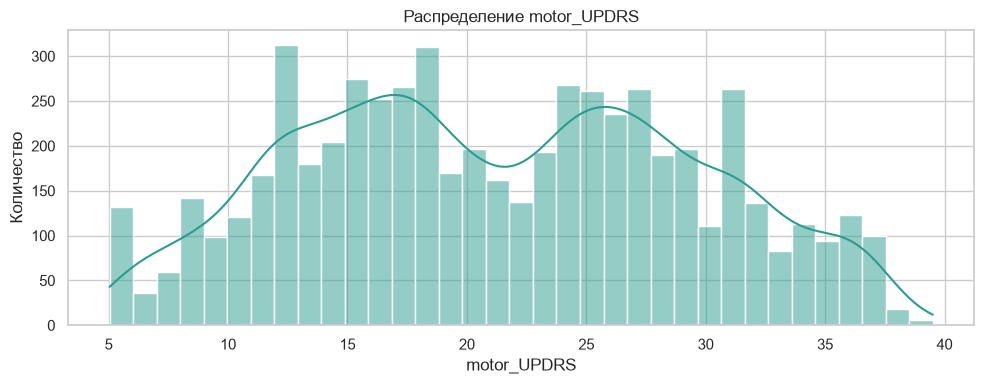

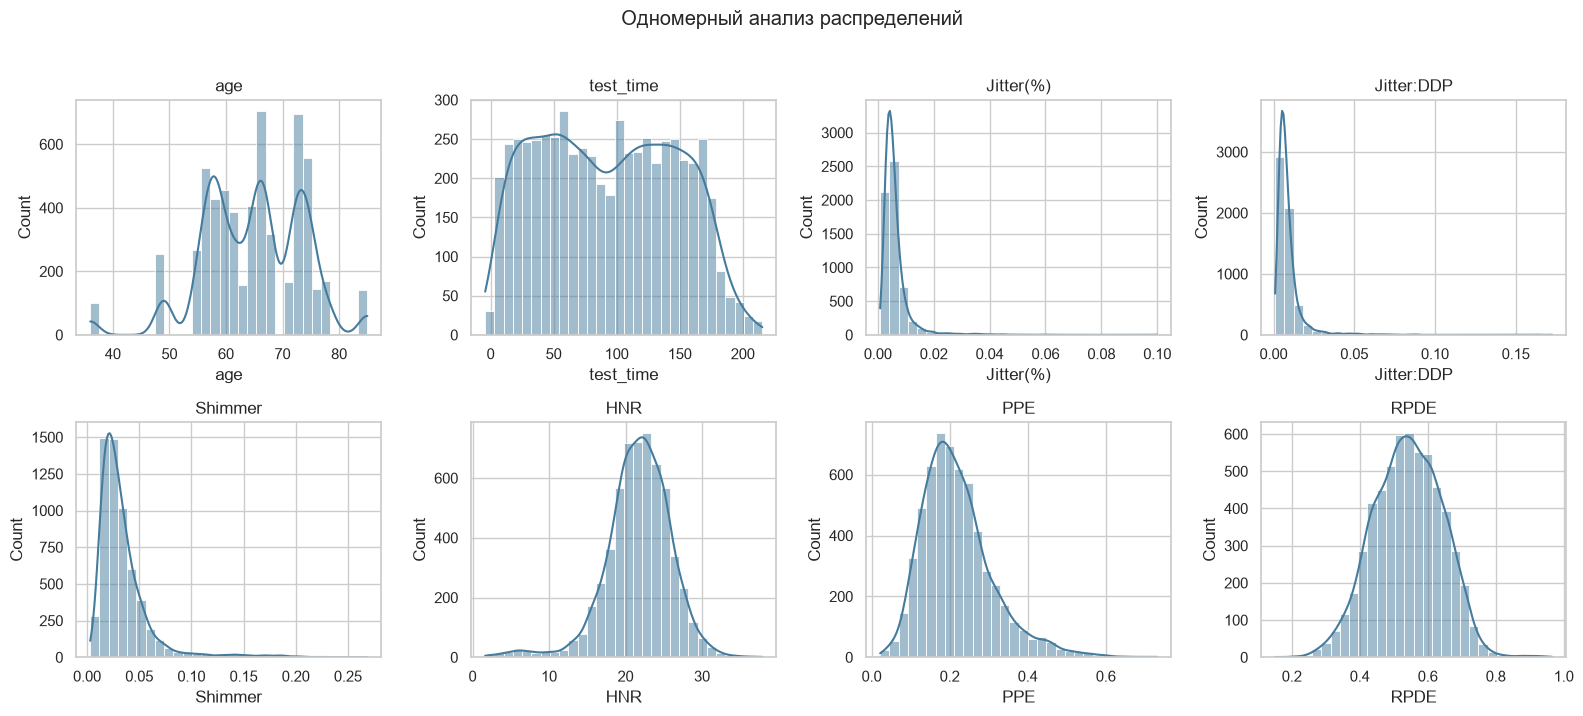

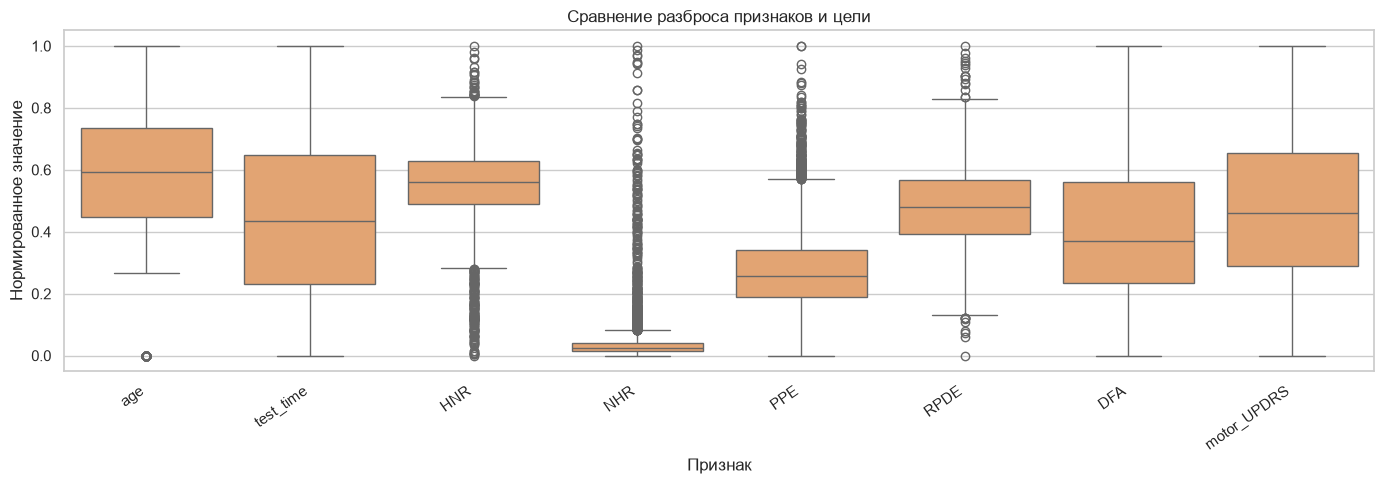

In [4]:
# Графики 1–3: цель, распределения и boxplot
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(df_raw[TARGET], bins=35, kde=True, ax=ax, color="#2a9d8f")
ax.set(title="Распределение motor_UPDRS", xlabel="motor_UPDRS", ylabel="Количество")
plt.tight_layout(); plt.show()

hist_cols = ["age", "test_time", "Jitter(%)", "Jitter:DDP", "Shimmer", "HNR", "PPE", "RPDE"]
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, hist_cols):
    sns.histplot(df_raw[col], bins=30, kde=True, ax=ax, color="#457b9d")
    ax.set_title(col)
plt.suptitle("Одномерный анализ распределений", y=1.02)
plt.tight_layout(); plt.show()

box_cols = ["age", "test_time", "HNR", "NHR", "PPE", "RPDE", "DFA", TARGET]
box_norm = (df_raw[box_cols] - df_raw[box_cols].min()) / (df_raw[box_cols].max() - df_raw[box_cols].min())
plt.figure(figsize=(14, 5))
sns.boxplot(data=box_norm.melt(var_name="Признак", value_name="Нормированное значение"),
            x="Признак", y="Нормированное значение", color="#f4a261")
plt.title("Сравнение разброса признаков и цели")
plt.xticks(rotation=35, ha="right")
plt.tight_layout(); plt.show()


### Пояснение

Проверяем пропуски, строим матрицу корреляций Пирсона с числовыми значениями в ячейках и показываем самые сильные связи с целью.

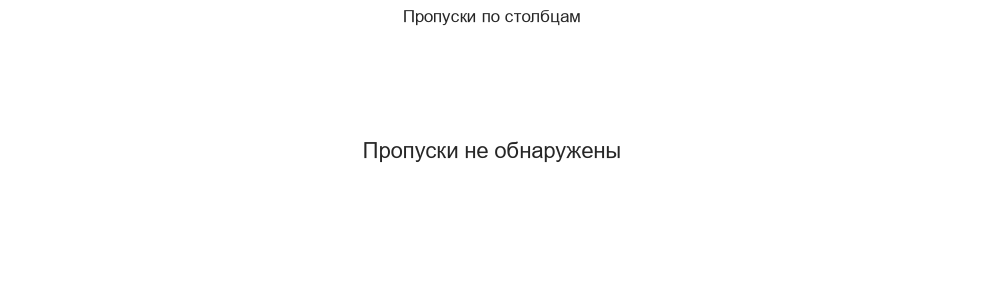

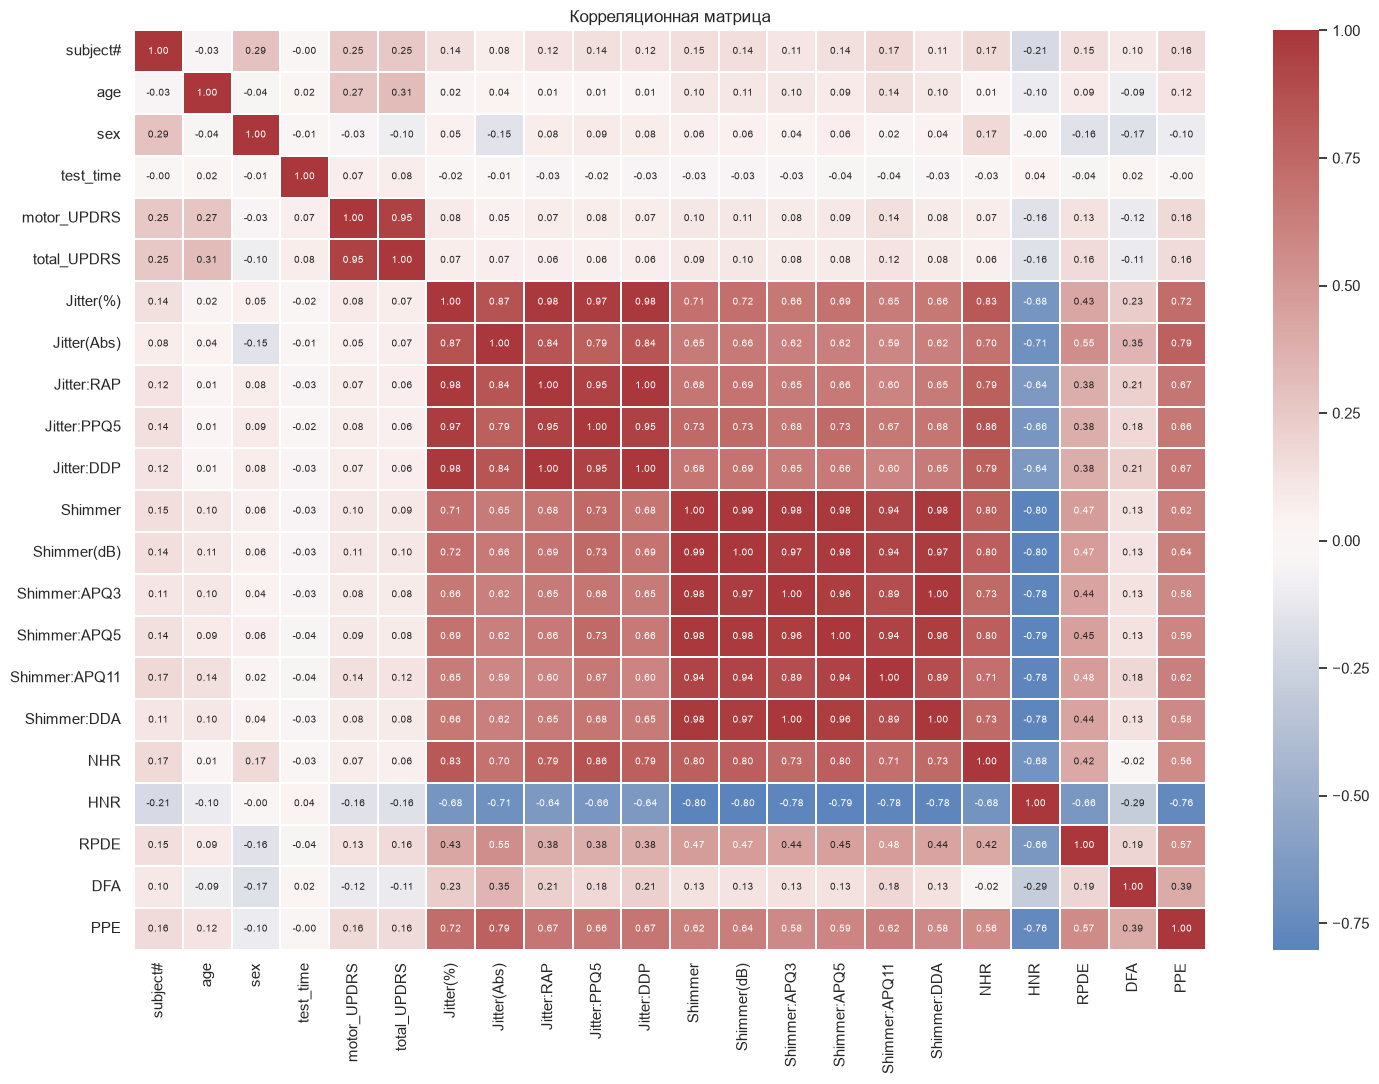

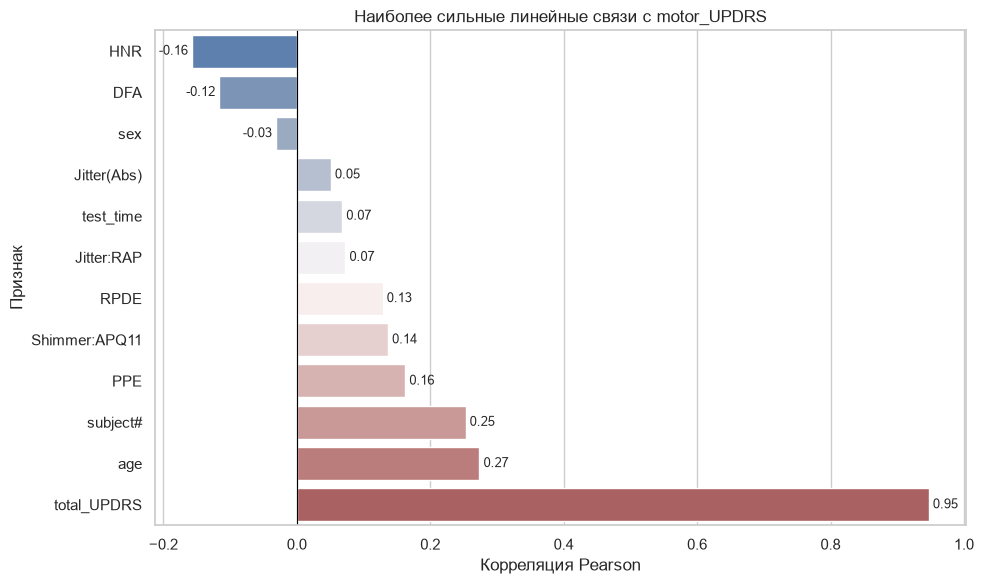

In [5]:
# Графики 4–6: пропуски и корреляции
missing_plot = missing_report[missing_report["missing_count"] > 0]
plt.figure(figsize=(10, 3))
if missing_plot.empty:
    plt.text(0.5, 0.5, "Пропуски не обнаружены", ha="center", va="center", fontsize=16)
    plt.axis("off")
else:
    sns.barplot(x=missing_plot.index, y=missing_plot["missing_count"], color="#e76f51")
    plt.xticks(rotation=60, ha="right")
    plt.ylabel("Количество пропусков")
plt.title("Пропуски по столбцам")
plt.tight_layout(); plt.show()

corr = df_raw.select_dtypes(include=np.number).corr()
plt.figure(figsize=(15, 11))
sns.heatmap(corr, cmap="vlag", center=0, linewidths=0.2, annot=True, fmt=".2f",
            annot_kws={"size": 7})
plt.title("Корреляционная матрица")
plt.tight_layout(); plt.show()

target_corr = corr[TARGET].drop(TARGET).sort_values()
top_corr = pd.concat([target_corr.head(6), target_corr.tail(6)]).sort_values()
plt.figure(figsize=(10, 6))
ax_corr = sns.barplot(x=top_corr.values, y=top_corr.index, hue=top_corr.index,
                      palette="vlag", legend=False)
for container in ax_corr.containers:
    ax_corr.bar_label(container, fmt="%.2f", padding=3, fontsize=9)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Наиболее сильные линейные связи с motor_UPDRS")
plt.xlabel("Корреляция Pearson"); plt.ylabel("Признак")
plt.tight_layout(); plt.show()


### Пояснение

Исследуем многомерные зависимости, пары признаков, количество измерений на пациента и динамику motor_UPDRS во времени.

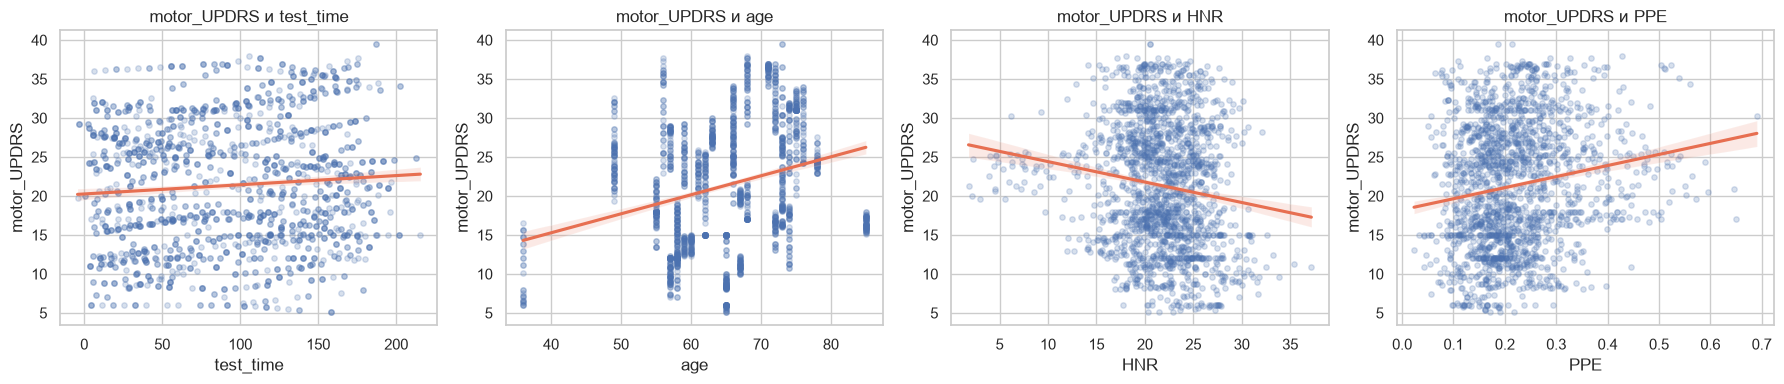

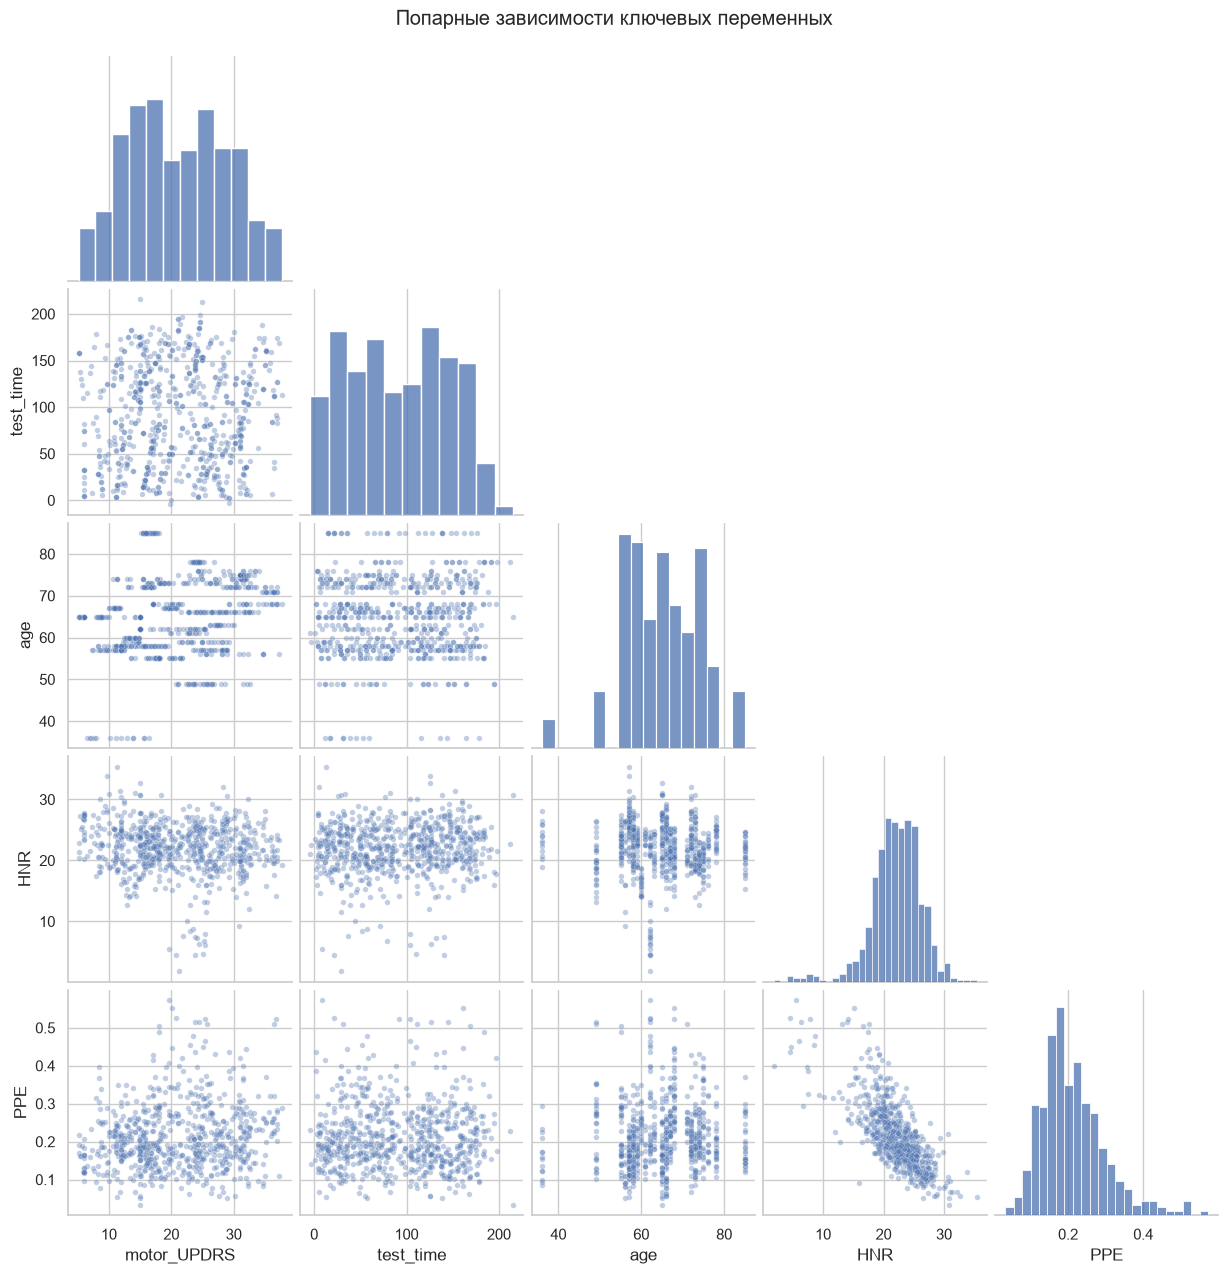

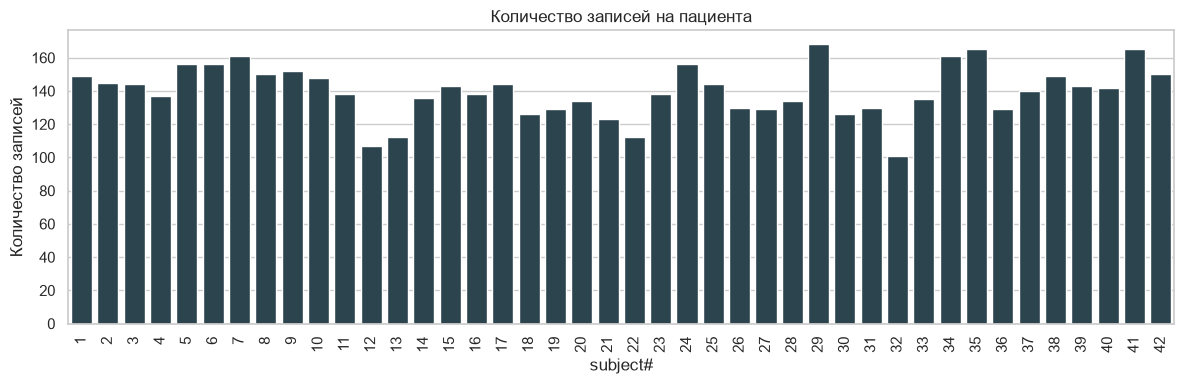

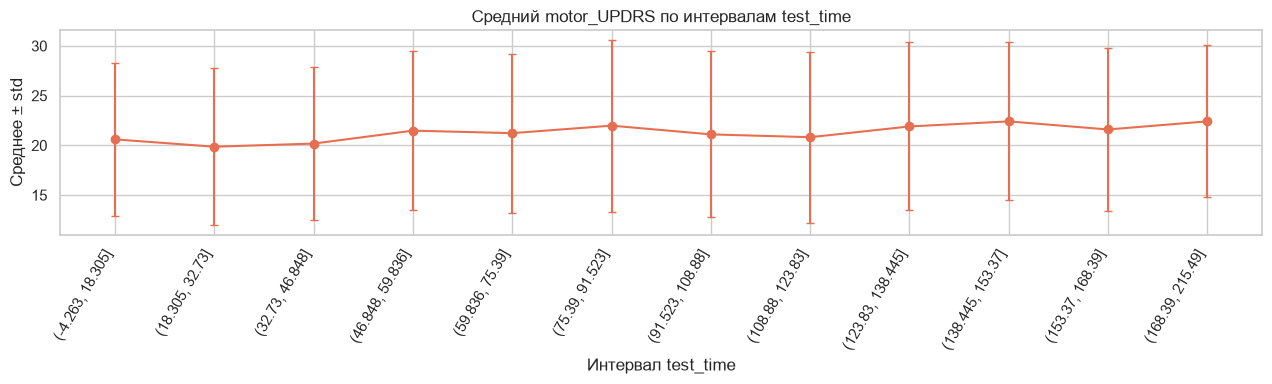

In [6]:
# Графики 7–10: многомерные зависимости и динамика
scatter_cols = ["test_time", "age", "HNR", "PPE"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
sample = df_raw.sample(min(1800, len(df_raw)), random_state=SEED)
for ax, col in zip(axes, scatter_cols):
    sns.regplot(data=sample, x=col, y=TARGET, scatter_kws={"alpha": 0.22, "s": 15},
                line_kws={"color": "#e76f51"}, ax=ax)
    ax.set_title(f"{TARGET} и {col}")
plt.tight_layout(); plt.show()

pair_cols = ["motor_UPDRS", "test_time", "age", "HNR", "PPE"]
sns.pairplot(df_raw[pair_cols].sample(min(700, len(df_raw)), random_state=SEED),
             corner=True, plot_kws={"alpha": 0.35, "s": 16})
plt.suptitle("Попарные зависимости ключевых переменных", y=1.02)
plt.show()

subject_counts = df_raw[ID_COLUMN].value_counts().sort_index()
plt.figure(figsize=(12, 4))
sns.barplot(x=subject_counts.index.astype(str), y=subject_counts.values, color="#264653")
plt.title("Количество записей на пациента")
plt.xlabel("subject#"); plt.ylabel("Количество записей")
plt.xticks(rotation=90)
plt.tight_layout(); plt.show()

time_bins = pd.qcut(df_raw["test_time"], q=12, duplicates="drop")
time_summary = df_raw.assign(time_bin=time_bins).groupby("time_bin", observed=True)[TARGET].agg(["mean", "std"]).reset_index()
time_summary["label"] = time_summary["time_bin"].astype(str)
plt.figure(figsize=(13, 4))
plt.errorbar(range(len(time_summary)), time_summary["mean"], yerr=time_summary["std"],
             marker="o", capsize=3, color="#e76f51")
plt.xticks(range(len(time_summary)), time_summary["label"], rotation=60, ha="right")
plt.title("Средний motor_UPDRS по интервалам test_time")
plt.xlabel("Интервал test_time"); plt.ylabel("Среднее ± std")
plt.tight_layout(); plt.show()


## Очистка данных и журнал удалений

Почти нулевым считается числовой признак, у которого одно уникальное значение либо доля уникальных значений не превышает 1%, а одно значение занимает не менее 99% строк. subject# удаляется как идентификатор, total_UPDRS — как запрещённая вариантом 6 утечка целевой информации.


### Пояснение

Ищем константные и почти нулевые признаки, которые не несут полезной изменчивой информации для модели.

In [7]:
# Поиск константных и почти нулевых признаков
def quasi_constant_report(frame, exclude=None, unique_share_threshold=0.01, dominant_share_threshold=0.99):
    exclude = set(exclude or [])
    rows = []
    for col in frame.select_dtypes(include=np.number).columns:
        if col in exclude:
            continue
        unique_share = frame[col].nunique(dropna=False) / len(frame)
        dominant_share = frame[col].value_counts(dropna=False, normalize=True).iloc[0]
        is_constant = frame[col].nunique(dropna=False) <= 1
        is_quasi = is_constant or (unique_share <= unique_share_threshold and dominant_share >= dominant_share_threshold)
        rows.append({
            "feature": col,
            "unique_count": int(frame[col].nunique(dropna=False)),
            "unique_share_%": round(unique_share * 100, 3),
            "dominant_share_%": round(dominant_share * 100, 3),
            "is_constant_or_near_zero": is_quasi,
        })
    return pd.DataFrame(rows).sort_values(["is_constant_or_near_zero", "unique_share_%"], ascending=[False, True])

near_zero_report = quasi_constant_report(df_raw, exclude=[TARGET, LEAKAGE_COLUMN])
display(near_zero_report)
near_zero_features = near_zero_report.loc[near_zero_report["is_constant_or_near_zero"], "feature"].tolist()


,feature,unique_count,unique_share_%,dominant_share_%,is_constant_or_near_zero
2,sex,2,0.034,68.221,False
1,age,23,0.391,7.302,False
0,subject#,42,0.715,2.860,False
7,Jitter:PPQ5,840,14.298,0.545,False
10,Shimmer(dB),852,14.502,0.562,False
6,Jitter:RAP,853,14.519,0.630,False
4,Jitter(%),1305,22.213,0.374,False
8,Jitter:DDP,1703,28.987,0.289,False
3,test_time,2442,41.566,0.255,False
11,Shimmer:APQ3,2664,45.345,0.170,False


### Пояснение

Удаляем подтверждённые дубликаты и недопустимые для входа признаки, формируя журнал каждого удаления.

In [8]:
# Очистка и полный журнал удаления признаков
df_clean = df_raw.drop_duplicates().copy()
duplicate_rows_removed = len(df_raw) - len(df_clean)
removal_log_rows = []

for col, reason in [
    (ID_COLUMN, "идентификатор пациента; не является измеряемым признаком"),
    (LEAKAGE_COLUMN, "утечка целевой информации; запрещён входным условием варианта 6"),
]:
    if col in df_clean.columns:
        removal_log_rows.append({"feature": col, "reason": reason})

for col in near_zero_features:
    if col not in {ID_COLUMN, LEAKAGE_COLUMN} and col in df_clean.columns:
        removal_log_rows.append({"feature": col, "reason": "константный или почти нулевой признак по зафиксированному порогу"})

removed_columns = [row["feature"] for row in removal_log_rows]
df_clean = df_clean.drop(columns=removed_columns, errors="ignore")
removal_log = pd.DataFrame(removal_log_rows, columns=["feature", "reason"])

print(f"Удалено дубликатов строк: {duplicate_rows_removed}")
print(f"Размер после очистки: {df_clean.shape[0]:,} × {df_clean.shape[1]}")
display(removal_log if not removal_log.empty else
        pd.DataFrame({"feature": ["<признаки не удалялись>"], "reason": ["Дополнительных удалений не найдено"]}))
display(df_clean.isna().sum().loc[lambda s: s > 0].rename("missing_count").to_frame())


Удалено дубликатов строк: 0
Размер после очистки: 5,875 × 20


,feature,reason
0,subject#,идентификатор пациента; не является измеряемым...
1,total_UPDRS,утечка целевой информации; запрещён входным ус...


,missing_count


## Разбиение, построение и преобразование признаков

Импьютер, Min-Max масштабировщик и отбор признаков обучаются только на train-части. Это исключает утечку статистик validation/test в процесс обучения.


### Пояснение

Делим данные на train, validation и test до обучения моделей, чтобы качество оценивалось на отложенных наблюдениях.

In [9]:
# Train / validation / test
X_full = df_clean.drop(columns=[TARGET])
y_full = df_clean[TARGET].astype(float)

X_train, X_temp, y_train, y_temp = train_test_split(X_full, y_full, test_size=0.30, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED)
print({"train": X_train.shape, "validation": X_val.shape, "test": X_test.shape})


{'train': (4112, 19), 'validation': (881, 19), 'test': (882, 19)}


### Пояснение

Создаём агрегированные признаки для джиттера, шиммера, шума и взаимодействия возраста со временем.

In [10]:
# Построение дополнительных признаков
def add_engineered_features(frame):
    out = frame.copy()
    jitter_cols = [c for c in ["Jitter(%)", "Jitter(Abs)", "Jitter:RAP", "Jitter:PPQ5", "Jitter:DDP"] if c in frame]
    shimmer_cols = [c for c in ["Shimmer", "Shimmer(dB)", "Shimmer:APQ3", "Shimmer:APQ5", "Shimmer:APQ11", "Shimmer:DDA"] if c in frame]
    if jitter_cols:
        out["jitter_mean"] = frame[jitter_cols].mean(axis=1)
        out["jitter_max"] = frame[jitter_cols].max(axis=1)
    if shimmer_cols:
        out["shimmer_mean"] = frame[shimmer_cols].mean(axis=1)
        out["shimmer_max"] = frame[shimmer_cols].max(axis=1)
    if {"NHR", "HNR"}.issubset(frame.columns):
        out["noise_to_harmonics_ratio"] = frame["NHR"] / (frame["HNR"].abs() + 1e-6)
    if {"age", "test_time"}.issubset(frame.columns):
        out["age_x_test_time"] = frame["age"] * frame["test_time"]
    return out.replace([np.inf, -np.inf], np.nan)

X_train_engineered = add_engineered_features(X_train)
X_val_engineered = add_engineered_features(X_val)
X_test_engineered = add_engineered_features(X_test)
print(f"Признаков до построения: {X_train.shape[1]}; после построения: {X_train_engineered.shape[1]}")


Признаков до построения: 19; после построения: 25


### Пояснение

Заполняем пропуски медианами, вычисленными на train, и отбираем признаки по F-тесту без использования validation и test статистик.

In [11]:
# Медианная импутация и отбор существенных признаков по F-test
def fit_select_k_best(X_fit, y_fit, X_other, k=15):
    imputer = SimpleImputer(strategy="median")
    X_fit_imp = imputer.fit_transform(X_fit)
    X_other_imp = imputer.transform(X_other)
    selector = SelectKBest(score_func=f_regression, k=min(k, X_fit_imp.shape[1]))
    X_fit_sel = selector.fit_transform(X_fit_imp, y_fit)
    X_other_sel = selector.transform(X_other_imp)
    scores = pd.DataFrame({
        "feature": X_fit.columns,
        "F_score": selector.scores_,
        "p_value": selector.pvalues_,
        "selected": selector.get_support(),
    }).sort_values("F_score", ascending=False)
    return X_fit_sel, X_other_sel, imputer, selector, scores

X_train_built, X_val_built, built_imputer, built_selector, feature_scores = fit_select_k_best(
    X_train_engineered, y_train, X_val_engineered, k=15
)
X_test_built = built_selector.transform(built_imputer.transform(X_test_engineered))
display(feature_scores.head(20).round(6))
print(f"Отобрано существенных признаков: {X_train_built.shape[1]}")


,feature,F_score,p_value,selected
0,age,334.694259,0.000000,True
15,HNR,113.923078,0.000000,True
18,PPE,110.324720,0.000000,True
12,Shimmer:APQ11,76.682056,0.000000,True
16,RPDE,71.902743,0.000000,True
24,age_x_test_time,66.953453,0.000000,True
17,DFA,56.272407,0.000000,True
9,Shimmer(dB),48.103844,0.000000,True
22,shimmer_max,48.103844,0.000000,True
21,shimmer_mean,45.336251,0.000000,True


Отобрано существенных признаков: 15


### Пояснение

Формируем варианты исходных и построенных признаков, с Min-Max масштабированием и без него, чтобы сравнение было контролируемым.

In [12]:
# Четыре набора: исходный, преобразованный исходный, построенный, преобразованный построенный
def impute_split(X_fit, X_val_part, X_test_part):
    imp = SimpleImputer(strategy="median")
    return imp.fit_transform(X_fit), imp.transform(X_val_part), imp.transform(X_test_part), imp

Xtr_original, Xv_original, Xt_original, original_imputer = impute_split(X_train, X_val, X_test)
Xtr_engineered, Xv_engineered, Xt_engineered, engineered_imputer = impute_split(
    X_train_engineered, X_val_engineered, X_test_engineered
)
original_scaler = MinMaxScaler().fit(Xtr_original)
built_scaler = MinMaxScaler().fit(X_train_built)

dataset_variants = {
    "original": {
        "X_train": Xtr_original, "X_val": Xv_original, "X_test": Xt_original,
        "description": "очищенные исходные признаки + медианная импутация",
    },
    "transformed_original": {
        "X_train": original_scaler.transform(Xtr_original),
        "X_val": original_scaler.transform(Xv_original),
        "X_test": original_scaler.transform(Xt_original),
        "description": "исходные признаки + импутация + Min-Max",
    },
    "built": {
        "X_train": X_train_built, "X_val": X_val_built, "X_test": X_test_built,
        "description": "построенные признаки + F-test отбор",
    },
    "transformed_built": {
        "X_train": built_scaler.transform(X_train_built),
        "X_val": built_scaler.transform(X_val_built),
        "X_test": built_scaler.transform(X_test_built),
        "description": "построенные/отобранные признаки + Min-Max",
    },
}
variant_report = pd.DataFrame([
    {"dataset": name, "train_rows": d["X_train"].shape[0],
     "features": d["X_train"].shape[1], "description": d["description"]}
    for name, d in dataset_variants.items()
])
display(variant_report)
assert all(np.isfinite(d["X_train"]).all() and np.isfinite(d["X_val"]).all() and np.isfinite(d["X_test"]).all()
           for d in dataset_variants.values())


,dataset,train_rows,features,description
0,original,4112,19,очищенные исходные признаки + медианная импутация
1,transformed_original,4112,19,исходные признаки + импутация + Min-Max
2,built,4112,15,построенные признаки + F-test отбор
3,transformed_built,4112,15,построенные/отобранные признаки + Min-Max


## Нейросетевые модели

Сначала сравниваются базовые Dense- и GRU-модели без регуляризации. Затем отдельным блоком проверяется влияние L2-регуляризации и Dropout. Для всех обучений используются MSE, EarlyStopping и ReduceLROnPlateau.

Поскольку строки являются отдельными табличными измерениями, GRU получает форму samples × 1 × features: один временной шаг содержит весь вектор признаков.


### Пояснение

Определяем метрики, конструкторы Dense и GRU, callbacks, графики обучения и общую функцию запуска эксперимента.

In [13]:
# Функции моделей и метрик
EPOCHS = 80
BATCH_SIZE = 64
EXPERIMENT_EPOCHS = 60

def regression_metrics(y_true, y_pred):
    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": float(r2_score(y_true, y_pred)),
    }

def build_dense_model(n_features, learning_rate=1e-3, dropout=0.0,
                      activation="relu", kernel_initializer="glorot_uniform",
                      use_regularization=False, hidden_units=(64, 32), l2_value=1e-4):
    if not TF_AVAILABLE:
        raise RuntimeError("Установите TensorFlow для Dense.")
    regularizer = tf.keras.regularizers.l2(l2_value) if use_regularization else None
    layers = [tf.keras.layers.Input(shape=(n_features,))]
    for units in hidden_units:
        layers.append(tf.keras.layers.Dense(
            units, activation=activation, kernel_initializer=kernel_initializer,
            kernel_regularizer=regularizer
        ))
        if dropout > 0:
            layers.append(tf.keras.layers.Dropout(dropout))
    layers.append(tf.keras.layers.Dense(1, kernel_initializer=kernel_initializer))
    model = tf.keras.Sequential([
        *layers,
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), loss="mse", metrics=["mae"])
    return model

def build_gru_model(n_features, units=64, learning_rate=1e-3, dropout=0.0,
                    activation="tanh", kernel_initializer="glorot_uniform",
                    recurrent_initializer="orthogonal", use_regularization=False,
                    dense_units=(32,), l2_value=1e-4):
    if not TF_AVAILABLE:
        raise RuntimeError("Установите TensorFlow для GRU.")
    regularizer = tf.keras.regularizers.l2(l2_value) if use_regularization else None
    layers = [
        tf.keras.layers.Input(shape=(1, n_features)),
        tf.keras.layers.GRU(
            units, activation=activation, recurrent_activation="sigmoid",
            dropout=dropout, recurrent_dropout=0.0,
            kernel_initializer=kernel_initializer,
            recurrent_initializer=recurrent_initializer,
            kernel_regularizer=regularizer,
            recurrent_regularizer=regularizer,
        ),
    ]
    for dense_size in dense_units:
        layers.append(tf.keras.layers.Dense(
            dense_size, activation=activation, kernel_initializer=kernel_initializer,
            kernel_regularizer=regularizer
        ))
        if dropout > 0:
            layers.append(tf.keras.layers.Dropout(dropout))
    layers.append(tf.keras.layers.Dense(1, kernel_initializer=kernel_initializer))
    model = tf.keras.Sequential([
        *layers,
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), loss="mse", metrics=["mae"])
    return model

def fit_neural_model(model, Xtr, ytr, Xv, yv, recurrent=False, epochs=EPOCHS):
    Xtr_model = Xtr.reshape(-1, 1, Xtr.shape[1]) if recurrent else Xtr
    Xv_model = Xv.reshape(-1, 1, Xv.shape[1]) if recurrent else Xv
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=6, min_lr=1e-6),
    ]
    return model.fit(Xtr_model, ytr, validation_data=(Xv_model, yv), epochs=epochs,
                     batch_size=BATCH_SIZE, verbose=0, callbacks=callbacks)

def predict_neural_model(model, X, recurrent=False):
    X_model = X.reshape(-1, 1, X.shape[1]) if recurrent else X
    return model.predict(X_model, verbose=0).ravel()

def plot_learning_curves(history, title):
    history_data = history.history
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(history_data["loss"], label="train")
    axes[0].plot(history_data["val_loss"], label="validation")
    axes[0].set(title=f"Learning curve: {title}", xlabel="Эпоха", ylabel="MSE loss")
    axes[0].legend()
    if "mae" in history_data:
        axes[1].plot(history_data["mae"], label="train")
        axes[1].plot(history_data["val_mae"], label="validation")
    axes[1].set(title=f"MAE curve: {title}", xlabel="Эпоха", ylabel="MAE")
    axes[1].legend()
    plt.tight_layout(); plt.show()

def plot_prediction_metrics(y_true, y_pred, title):
    residuals = np.asarray(y_true) - np.asarray(y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.35, s=18, ax=axes[0], color="#457b9d")
    limits = [min(np.min(y_true), np.min(y_pred)), max(np.max(y_true), np.max(y_pred))]
    axes[0].plot(limits, limits, "--", color="#e76f51")
    axes[0].set(title=f"Факт и прогноз: {title}", xlabel="Фактический motor_UPDRS", ylabel="Прогноз")
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.35, s=18, ax=axes[1], color="#2a9d8f")
    axes[1].axhline(0, color="#e76f51", linestyle="--")
    axes[1].set(title=f"Остатки: {title}", xlabel="Прогноз", ylabel="Остаток")
    plt.tight_layout(); plt.show()

experiment_records = []
experiment_models = {}
experiment_histories = {}
EXPERIMENT_DATASET = "transformed_original"

def run_experiment(name, model_type, activation, kernel_initializer,
                   recurrent_initializer=None, use_regularization=False,
                   dropout=0.0, hidden_units=(64, 32), gru_units=64,
                   dense_units=(32,), l2_value=1e-4):
    if not TF_AVAILABLE:
        print("Установите TensorFlow для запуска экспериментов.")
        return None
    recurrent = model_type == "GRU"
    dataset = dataset_variants[EXPERIMENT_DATASET]
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)
    print("=" * 80)
    print("АРХИТЕКТУРА, КОТОРАЯ ОБУЧАЕТСЯ")
    print(f"Эксперимент: {name}")
    print(f"Модель: {model_type}; активация: {activation}; инициализация: {kernel_initializer}")
    if recurrent:
        print(f"Рекуррентная инициализация: {recurrent_initializer or 'orthogonal'}")
    print(f"Регуляризация: {'L2=' + str(l2_value) + ' + Dropout=' + str(dropout) if use_regularization else 'нет'}")
    print(f"Вход: {dataset['X_train'].shape[1]} признаков; набор: {EXPERIMENT_DATASET}")
    if model_type == "Dense":
        model = build_dense_model(
            dataset["X_train"].shape[1], activation=activation,
            kernel_initializer=kernel_initializer, use_regularization=use_regularization,
            dropout=dropout, hidden_units=hidden_units, l2_value=l2_value
        )
    else:
        model = build_gru_model(
            dataset["X_train"].shape[1], units=gru_units, activation=activation,
            kernel_initializer=kernel_initializer,
            recurrent_initializer=recurrent_initializer or "orthogonal",
            use_regularization=use_regularization, dropout=dropout,
            dense_units=dense_units, l2_value=l2_value
        )
    model.summary()
    history = fit_neural_model(
        model, dataset["X_train"], y_train.values, dataset["X_val"], y_val.values,
        recurrent=recurrent, epochs=EXPERIMENT_EPOCHS
    )
    train_pred = predict_neural_model(model, dataset["X_train"], recurrent)
    val_pred = predict_neural_model(model, dataset["X_val"], recurrent)
    train_metrics = regression_metrics(y_train, train_pred)
    val_metrics = regression_metrics(y_val, val_pred)
    print(f"Обучение завершено за {len(history.history['loss'])} эпох")
    print(f"Train: RMSE={train_metrics['RMSE']:.4f}, R²={train_metrics['R2']:.4f}")
    print(f"Validation: RMSE={val_metrics['RMSE']:.4f}, R²={val_metrics['R2']:.4f}")
    plot_learning_curves(history, name)
    plot_prediction_metrics(y_val.values, val_pred, name)
    result = {
        "experiment": name, "model": model_type, "activation": activation,
        "initializer": kernel_initializer,
        "recurrent_initializer": recurrent_initializer if recurrent else "—",
        "regularization": "L2 + Dropout" if use_regularization else "нет",
        "train_RMSE": train_metrics["RMSE"], "train_R2": train_metrics["R2"],
        "val_RMSE": val_metrics["RMSE"], "val_R2": val_metrics["R2"],
        "epochs_used": len(history.history["loss"]),
    }
    experiment_records.append(result)
    experiment_models[name] = model
    experiment_histories[name] = history
    return result


### Пояснение

Получаем базовую таблицу сравнения Dense и GRU на четырёх подготовленных наборах данных.

In [14]:
# Обучение Dense и GRU на четырёх наборах
model_store, history_store, comparison_rows = {}, {}, []

if not TF_AVAILABLE:
    display(Markdown("**Модели пока не обучены:** установите TensorFlow и перезапустите ноутбук с этой ячейки."))
    comparison_results = pd.DataFrame(columns=["dataset", "model", "train_RMSE", "train_R2", "val_RMSE", "val_R2"])
else:
    for dataset_name, dataset in dataset_variants.items():
        for model_name, builder, recurrent in [
            ("Dense", build_dense_model, False), ("GRU", build_gru_model, True)
        ]:
            tf.keras.backend.clear_session()
            tf.keras.utils.set_random_seed(SEED)
            model = builder(dataset["X_train"].shape[1])
            history = fit_neural_model(model, dataset["X_train"], y_train.values,
                                       dataset["X_val"], y_val.values, recurrent)
            train_m = regression_metrics(y_train, predict_neural_model(model, dataset["X_train"], recurrent))
            val_m = regression_metrics(y_val, predict_neural_model(model, dataset["X_val"], recurrent))
            comparison_rows.append({
                "dataset": dataset_name, "model": model_name,
                "train_RMSE": train_m["RMSE"], "train_R2": train_m["R2"],
                "val_RMSE": val_m["RMSE"], "val_R2": val_m["R2"],
                "epochs_used": len(history.history["loss"]),
            })
            model_store[(dataset_name, model_name)] = model
            history_store[(dataset_name, model_name)] = history
    comparison_results = pd.DataFrame(comparison_rows).sort_values("val_RMSE")
    display(comparison_results.round(4))


,dataset,model,train_RMSE,train_R2,val_RMSE,val_R2,epochs_used
2,transformed_original,Dense,5.9195,0.4727,5.8383,0.4534,80
3,transformed_original,GRU,6.2425,0.4136,6.0348,0.4160,80
6,transformed_built,Dense,6.9384,0.2756,6.6746,0.2856,80
1,original,GRU,6.9681,0.2694,6.9221,0.2316,80
7,transformed_built,GRU,7.1872,0.2227,7.0815,0.1958,80
0,original,Dense,7.5260,0.1477,7.3597,0.1314,80
5,built,GRU,8.1516,0.0001,7.9005,-0.0010,80
4,built,Dense,8.2864,-0.0332,8.0415,-0.0370,21


## Эксперименты с активациями, инициализациями и архитектурами

Каждый следующий блок обучает отдельную модель на одном и том же наборе `transformed_original`. Перед запуском `fit()` блок выводит архитектуру модели, функцию активации и способ инициализации. После обучения выводятся RMSE/R² и графики loss, MAE, фактических значений и прогнозов.

В базовых экспериментах регуляризация отключена. Её влияние проверяется отдельно ниже.


### Пояснение

Запускаем отдельный эксперимент. Перед fit выводятся архитектура, активация, инициализация и регуляризация; после fit строятся графики loss, MAE, прогнозов и остатков.

АРХИТЕКТУРА, КОТОРАЯ ОБУЧАЕТСЯ
Эксперимент: Dense: ReLU + GlorotUniform, без регуляризации
Модель: Dense; активация: relu; инициализация: glorot_uniform
Регуляризация: нет
Вход: 19 признаков; набор: transformed_original


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

Обучение завершено за 60 эпох
Train: RMSE=6.1925, R²=0.4230
Validation: RMSE=6.0683, R²=0.4095


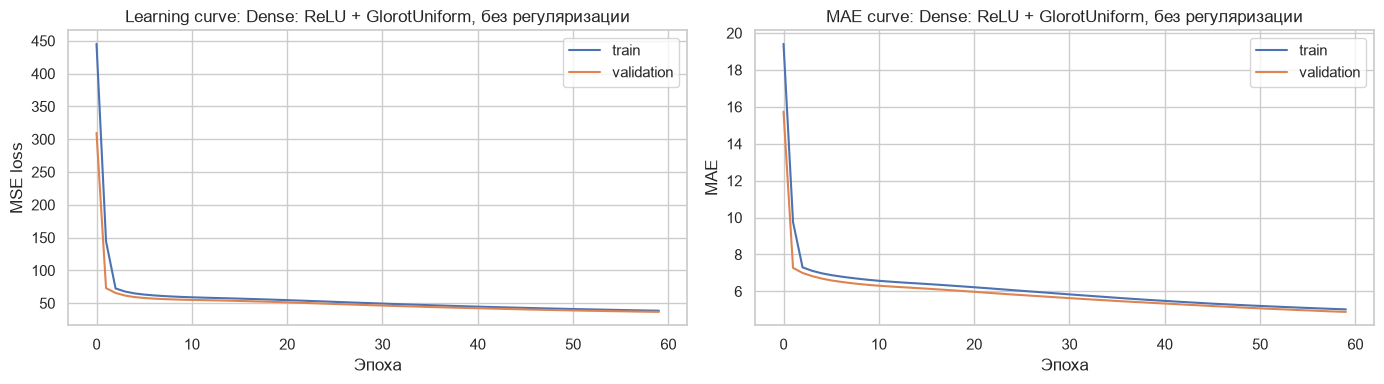

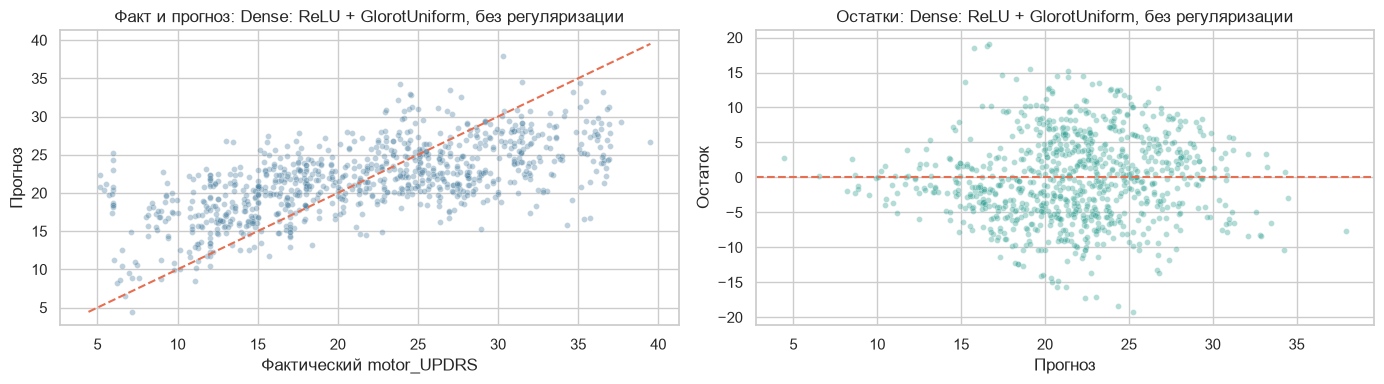

In [15]:
# Эксперимент 1: базовая Dense с ReLU и GlorotUniform без регуляризации
exp_dense_relu = run_experiment(
    name="Dense: ReLU + GlorotUniform, без регуляризации",
    model_type="Dense", activation="relu", kernel_initializer="glorot_uniform",
    use_regularization=False, hidden_units=(64, 32)
)


### Пояснение

Запускаем отдельный эксперимент. Перед fit выводятся архитектура, активация, инициализация и регуляризация; после fit строятся графики loss, MAE, прогнозов и остатков.

АРХИТЕКТУРА, КОТОРАЯ ОБУЧАЕТСЯ
Эксперимент: Dense: tanh + GlorotUniform, без регуляризации
Модель: Dense; активация: tanh; инициализация: glorot_uniform
Регуляризация: нет
Вход: 19 признаков; набор: transformed_original


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

Обучение завершено за 60 эпох
Train: RMSE=6.4741, R²=0.3693
Validation: RMSE=6.2723, R²=0.3691


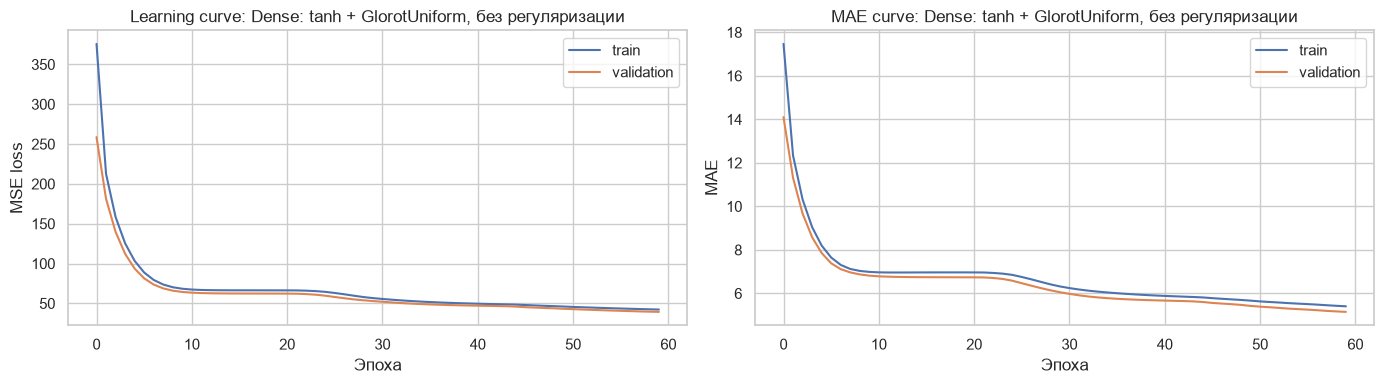

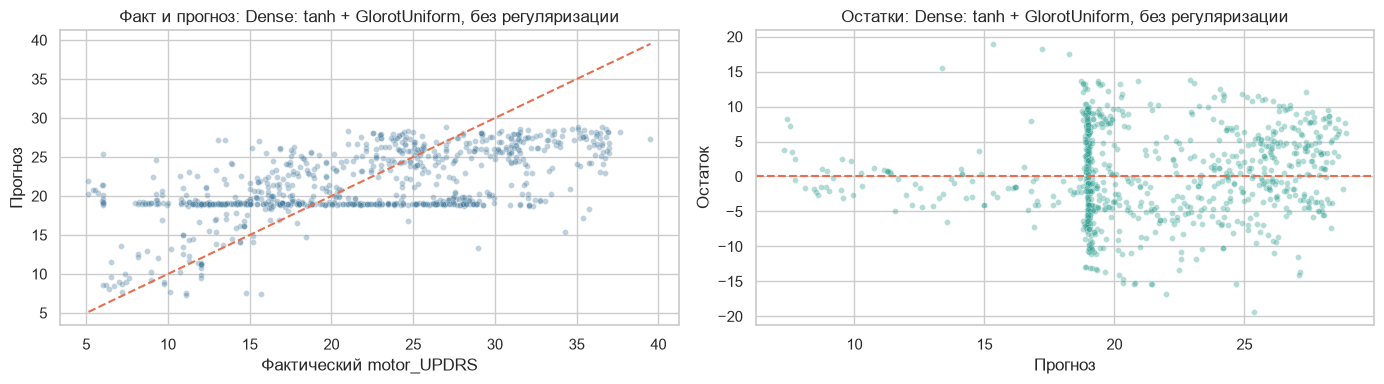

In [16]:
# Эксперимент 2: Dense с гиперболическим тангенсом и GlorotUniform без регуляризации
exp_dense_tanh = run_experiment(
    name="Dense: tanh + GlorotUniform, без регуляризации",
    model_type="Dense", activation="tanh", kernel_initializer="glorot_uniform",
    use_regularization=False, hidden_units=(64, 32)
)


### Пояснение

Запускаем отдельный эксперимент. Перед fit выводятся архитектура, активация, инициализация и регуляризация; после fit строятся графики loss, MAE, прогнозов и остатков.

АРХИТЕКТУРА, КОТОРАЯ ОБУЧАЕТСЯ
Эксперимент: Dense: tanh + Orthogonal, без регуляризации
Модель: Dense; активация: tanh; инициализация: orthogonal
Регуляризация: нет
Вход: 19 признаков; набор: transformed_original


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

Обучение завершено за 60 эпох
Train: RMSE=6.6197, R²=0.3406
Validation: RMSE=6.4329, R²=0.3364


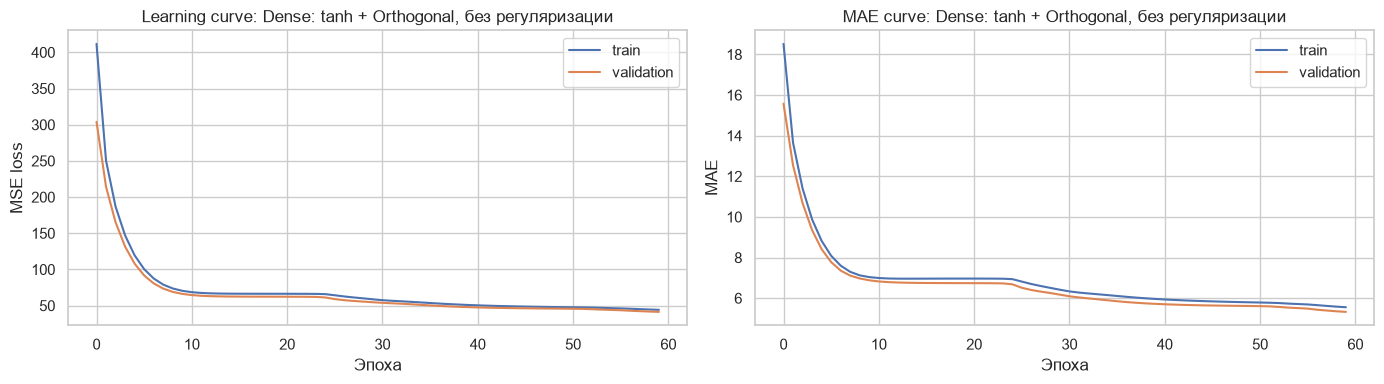

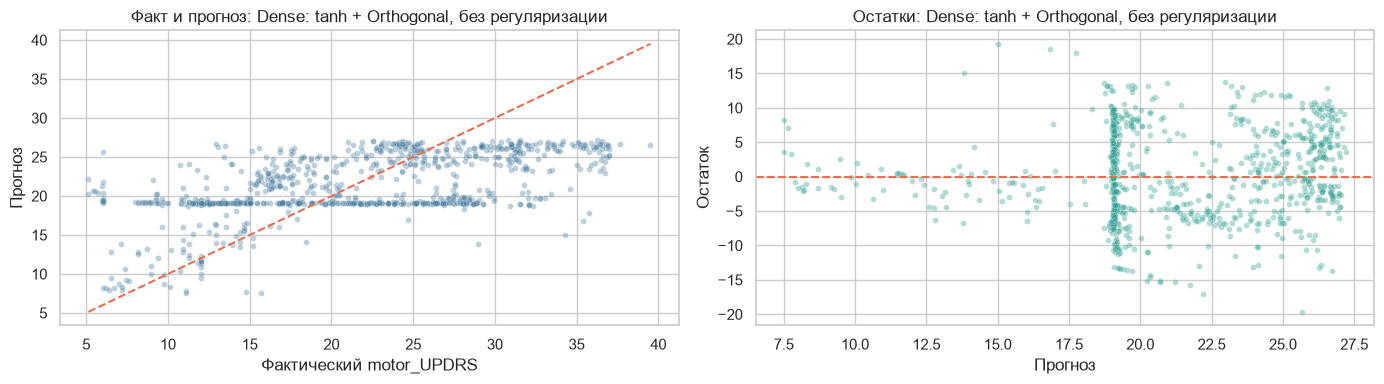

In [17]:
# Эксперимент 3: Dense с tanh и Orthogonal без регуляризации
exp_dense_tanh_orthogonal = run_experiment(
    name="Dense: tanh + Orthogonal, без регуляризации",
    model_type="Dense", activation="tanh", kernel_initializer="orthogonal",
    use_regularization=False, hidden_units=(64, 32)
)


### Пояснение

Запускаем отдельный эксперимент. Перед fit выводятся архитектура, активация, инициализация и регуляризация; после fit строятся графики loss, MAE, прогнозов и остатков.

АРХИТЕКТУРА, КОТОРАЯ ОБУЧАЕТСЯ
Эксперимент: GRU: tanh + GlorotUniform/Orthogonal, без регуляризации
Модель: GRU; активация: tanh; инициализация: glorot_uniform
Рекуррентная инициализация: orthogonal
Регуляризация: нет
Вход: 19 признаков; набор: transformed_original


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        16,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,433 (72.00 KB)

 Trainable params: 18,433 (72.00 KB)

 Non-trainable params: 0 (0.00 B)

Обучение завершено за 60 эпох
Train: RMSE=6.9030, R²=0.2830
Validation: RMSE=6.7729, R²=0.2644


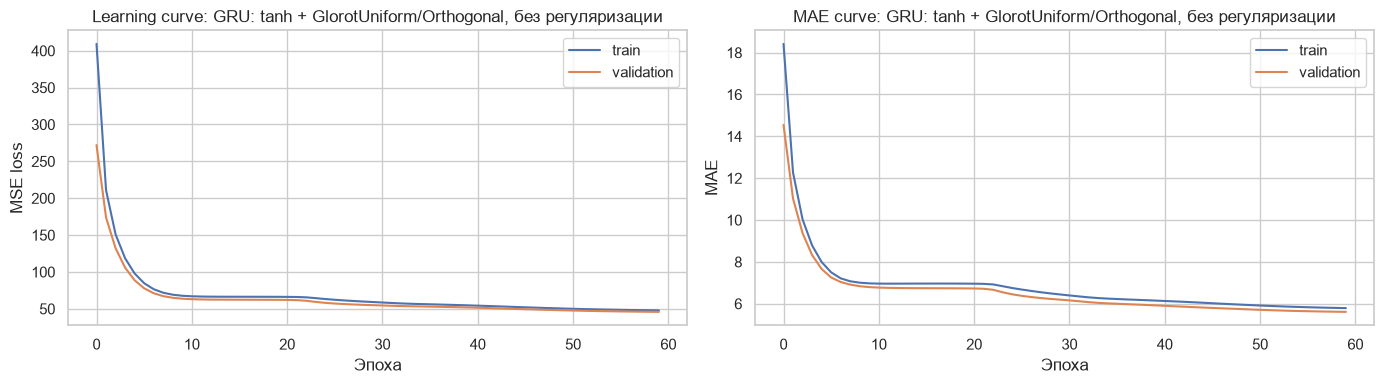

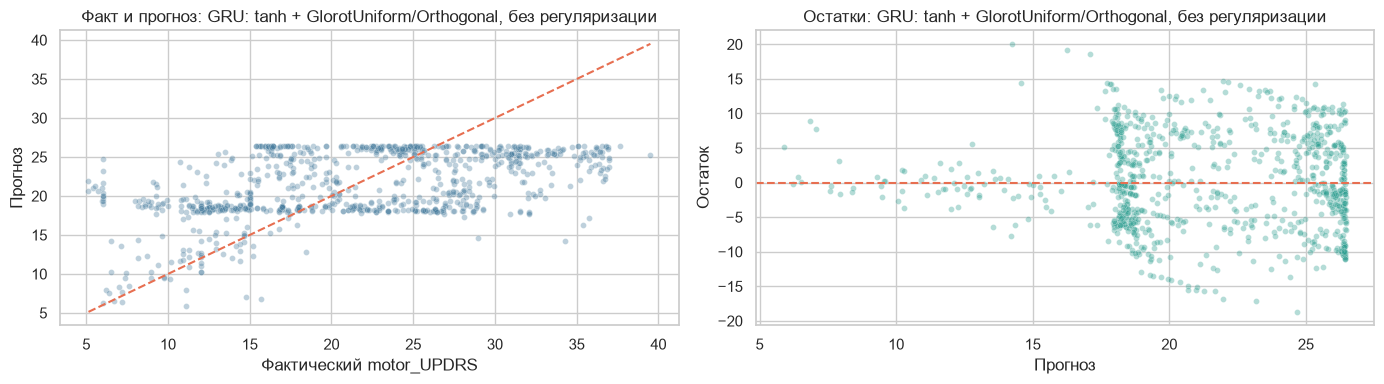

In [18]:
# Эксперимент 4: GRU с tanh, GlorotUniform и Orthogonal без регуляризации
exp_gru_tanh = run_experiment(
    name="GRU: tanh + GlorotUniform/Orthogonal, без регуляризации",
    model_type="GRU", activation="tanh", kernel_initializer="glorot_uniform",
    recurrent_initializer="orthogonal", use_regularization=False, dense_units=(32,)
)


### Пояснение

Запускаем отдельный эксперимент. Перед fit выводятся архитектура, активация, инициализация и регуляризация; после fit строятся графики loss, MAE, прогнозов и остатков.

АРХИТЕКТУРА, КОТОРАЯ ОБУЧАЕТСЯ
Эксперимент: Глубокая GRU: tanh + два Dense-слоя, без регуляризации
Модель: GRU; активация: tanh; инициализация: glorot_uniform
Рекуррентная инициализация: orthogonal
Регуляризация: нет
Вход: 19 признаков; набор: transformed_original


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        16,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,593 (88.25 KB)

 Trainable params: 22,593 (88.25 KB)

 Non-trainable params: 0 (0.00 B)

Обучение завершено за 60 эпох
Train: RMSE=6.1775, R²=0.4258
Validation: RMSE=5.9458, R²=0.4331


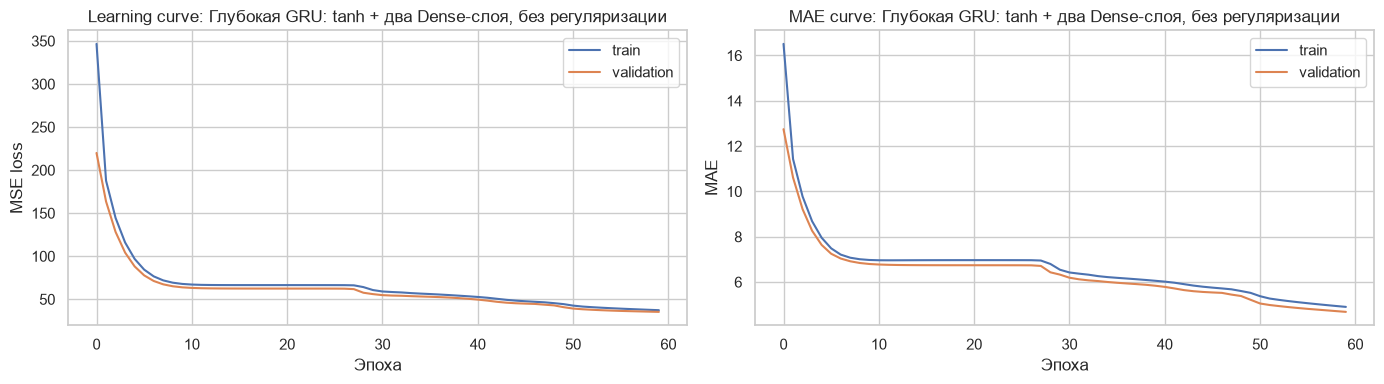

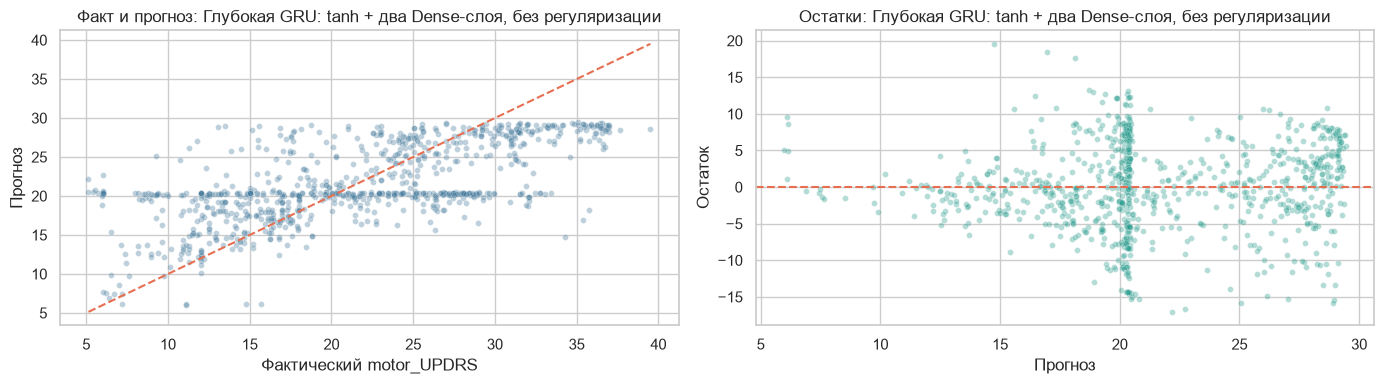

In [19]:
# Эксперимент 5: более глубокая GRU с tanh без регуляризации
exp_gru_deep = run_experiment(
    name="Глубокая GRU: tanh + два Dense-слоя, без регуляризации",
    model_type="GRU", activation="tanh", kernel_initializer="glorot_uniform",
    recurrent_initializer="orthogonal", use_regularization=False, dense_units=(64, 32)
)


### Пояснение

Сводим результаты базовых экспериментов в одну таблицу и сравниваем RMSE и R² на validation.

In [20]:
# Сводная таблица базовых экспериментов
if experiment_records:
    base_experiment_results = pd.DataFrame(experiment_records)
    display(base_experiment_results.round(4))
else:
    base_experiment_results = pd.DataFrame()


,experiment,model,activation,initializer,recurrent_initializer,regularization,train_RMSE,train_R2,val_RMSE,val_R2,epochs_used
0,"Dense: ReLU + GlorotUniform, без регуляризации",Dense,relu,glorot_uniform,—,нет,6.1925,0.4230,6.0683,0.4095,60
1,"Dense: tanh + GlorotUniform, без регуляризации",Dense,tanh,glorot_uniform,—,нет,6.4741,0.3693,6.2723,0.3691,60
2,"Dense: tanh + Orthogonal, без регуляризации",Dense,tanh,orthogonal,—,нет,6.6197,0.3406,6.4329,0.3364,60
3,"GRU: tanh + GlorotUniform/Orthogonal, без регу...",GRU,tanh,glorot_uniform,orthogonal,нет,6.9030,0.2830,6.7729,0.2644,60
4,"Глубокая GRU: tanh + два Dense-слоя, без регул...",GRU,tanh,glorot_uniform,orthogonal,нет,6.1775,0.4258,5.9458,0.4331,60


## Отдельный блок: влияние регуляризации

В этом блоке те же типы моделей обучаются с L2-регуляризацией и Dropout. Сравнение с предыдущими результатами позволяет оценить, уменьшает ли регуляризация переобучение и улучшает ли качество на validation.


### Пояснение

Запускаем отдельный эксперимент. Перед fit выводятся архитектура, активация, инициализация и регуляризация; после fit строятся графики loss, MAE, прогнозов и остатков.

АРХИТЕКТУРА, КОТОРАЯ ОБУЧАЕТСЯ
Эксперимент: Dense: tanh + GlorotUniform + L2 + Dropout
Модель: Dense; активация: tanh; инициализация: glorot_uniform
Регуляризация: L2=0.0001 + Dropout=0.15
Вход: 19 признаков; набор: transformed_original


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

Обучение завершено за 60 эпох
Train: RMSE=6.6335, R²=0.3379
Validation: RMSE=6.4309, R²=0.3368


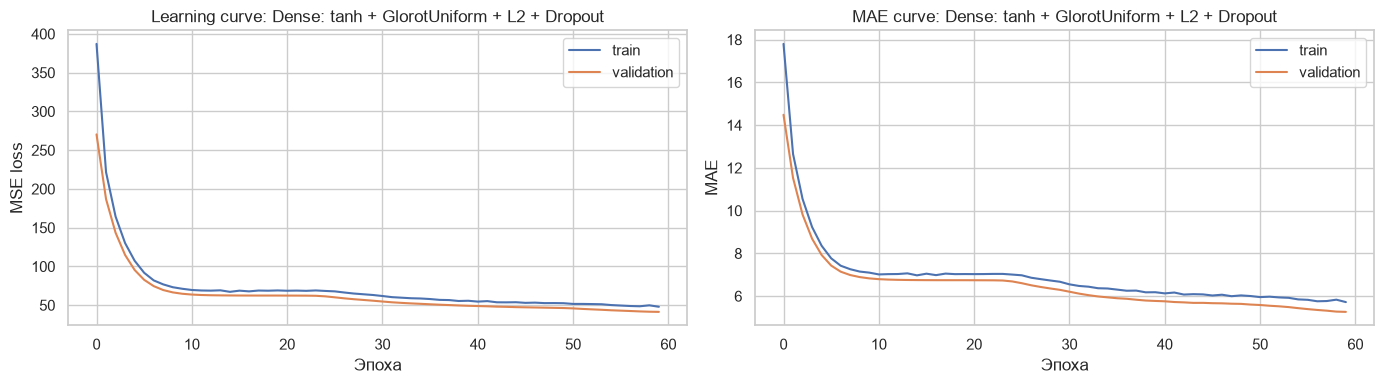

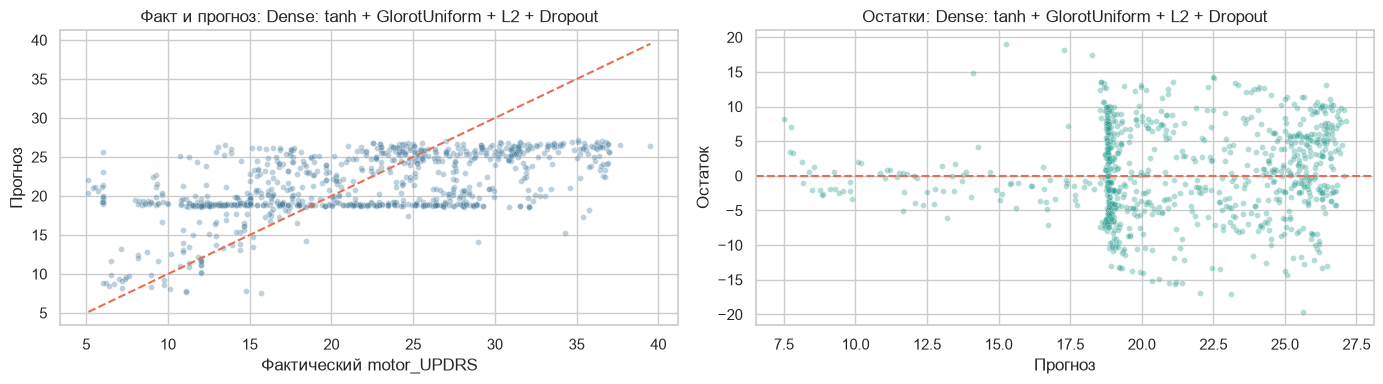

In [21]:
# Эксперимент 6: Dense с tanh и регуляризацией L2 + Dropout
exp_dense_regularized = run_experiment(
    name="Dense: tanh + GlorotUniform + L2 + Dropout",
    model_type="Dense", activation="tanh", kernel_initializer="glorot_uniform",
    use_regularization=True, dropout=0.15, hidden_units=(64, 32), l2_value=1e-4
)


### Пояснение

Запускаем отдельный эксперимент. Перед fit выводятся архитектура, активация, инициализация и регуляризация; после fit строятся графики loss, MAE, прогнозов и остатков.

АРХИТЕКТУРА, КОТОРАЯ ОБУЧАЕТСЯ
Эксперимент: GRU: tanh + GlorotUniform/Orthogonal + L2 + Dropout
Модель: GRU; активация: tanh; инициализация: glorot_uniform
Рекуррентная инициализация: orthogonal
Регуляризация: L2=0.0001 + Dropout=0.15
Вход: 19 признаков; набор: transformed_original


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        16,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,433 (72.00 KB)

 Trainable params: 18,433 (72.00 KB)

 Non-trainable params: 0 (0.00 B)

Обучение завершено за 60 эпох
Train: RMSE=7.6289, R²=0.1242
Validation: RMSE=7.3915, R²=0.1238


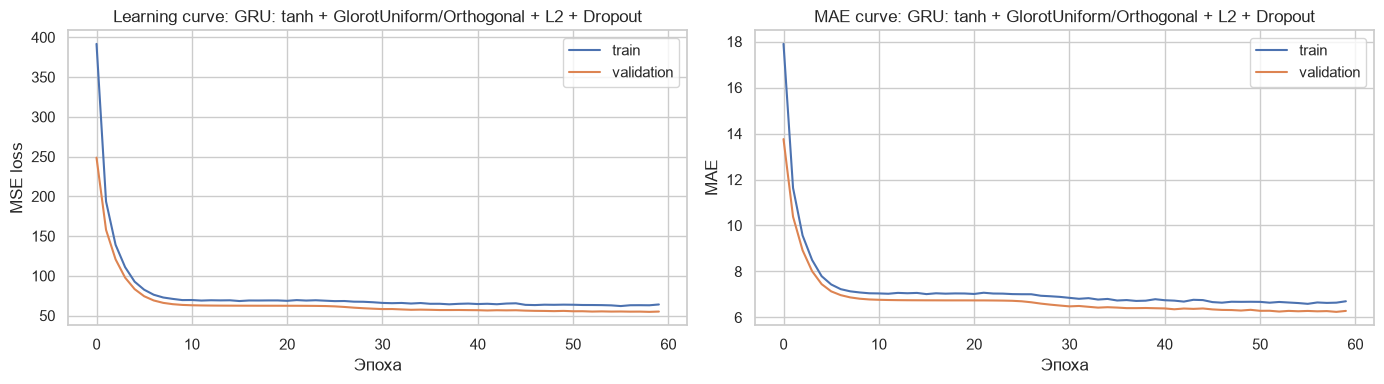

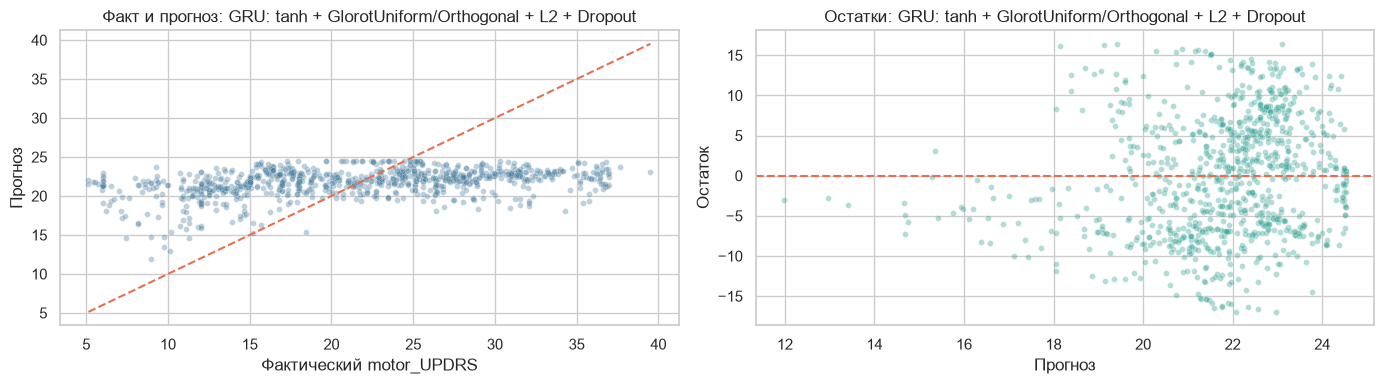

In [22]:
# Эксперимент 7: GRU с tanh и регуляризацией L2 + Dropout
exp_gru_regularized = run_experiment(
    name="GRU: tanh + GlorotUniform/Orthogonal + L2 + Dropout",
    model_type="GRU", activation="tanh", kernel_initializer="glorot_uniform",
    recurrent_initializer="orthogonal", use_regularization=True,
    dropout=0.15, dense_units=(32,), l2_value=1e-4
)


### Пояснение

Сравниваем базовые модели с отдельными вариантами, где включены L2-регуляризация и Dropout.

In [23]:
# Сравнение экспериментов с регуляризацией и без неё
if experiment_records:
    experiment_results = pd.DataFrame(experiment_records).sort_values("val_RMSE")
    display(experiment_results.round(4))
else:
    experiment_results = pd.DataFrame()


,experiment,model,activation,initializer,recurrent_initializer,regularization,train_RMSE,train_R2,val_RMSE,val_R2,epochs_used
4,"Глубокая GRU: tanh + два Dense-слоя, без регул...",GRU,tanh,glorot_uniform,orthogonal,нет,6.1775,0.4258,5.9458,0.4331,60
0,"Dense: ReLU + GlorotUniform, без регуляризации",Dense,relu,glorot_uniform,—,нет,6.1925,0.4230,6.0683,0.4095,60
1,"Dense: tanh + GlorotUniform, без регуляризации",Dense,tanh,glorot_uniform,—,нет,6.4741,0.3693,6.2723,0.3691,60
5,Dense: tanh + GlorotUniform + L2 + Dropout,Dense,tanh,glorot_uniform,—,L2 + Dropout,6.6335,0.3379,6.4309,0.3368,60
2,"Dense: tanh + Orthogonal, без регуляризации",Dense,tanh,orthogonal,—,нет,6.6197,0.3406,6.4329,0.3364,60
3,"GRU: tanh + GlorotUniform/Orthogonal, без регу...",GRU,tanh,glorot_uniform,orthogonal,нет,6.9030,0.2830,6.7729,0.2644,60
6,GRU: tanh + GlorotUniform/Orthogonal + L2 + Dr...,GRU,tanh,glorot_uniform,orthogonal,L2 + Dropout,7.6289,0.1242,7.3915,0.1238,60


### Пояснение

Показываем динамику обучения лучшей validation-модели и распределение её остатков.

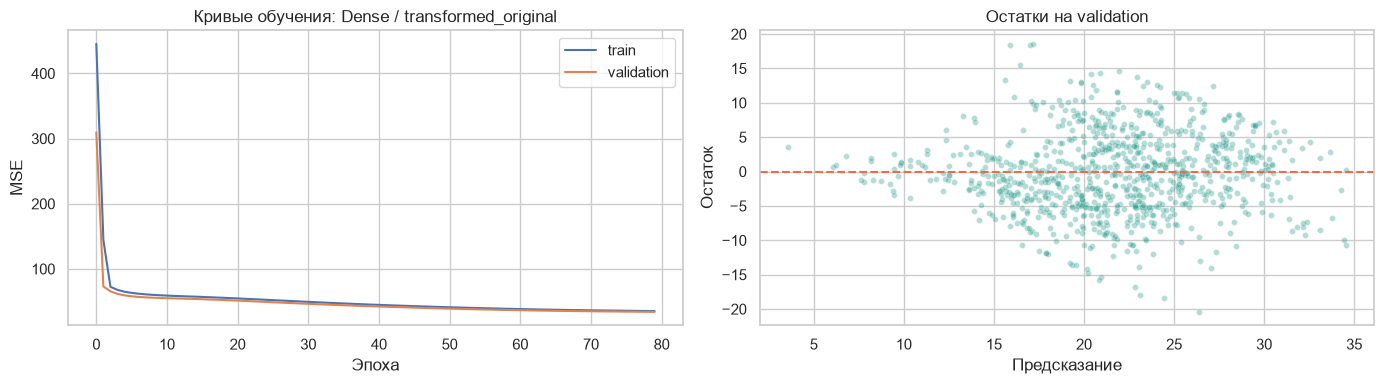

In [24]:
# Кривые обучения и остатки лучшей validation-модели
if TF_AVAILABLE and not comparison_results.empty:
    best_row = comparison_results.iloc[0]
    best_key = (best_row["dataset"], best_row["model"])
    history = history_store[best_key]
    recurrent = best_key[1] == "GRU"
    pred = predict_neural_model(model_store[best_key], dataset_variants[best_key[0]]["X_val"], recurrent)
    residuals = y_val.values - pred
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(history.history["loss"], label="train")
    axes[0].plot(history.history["val_loss"], label="validation")
    axes[0].set(title=f"Кривые обучения: {best_key[1]} / {best_key[0]}", xlabel="Эпоха", ylabel="MSE")
    axes[0].legend()
    sns.scatterplot(x=pred, y=residuals, alpha=0.35, s=18, ax=axes[1], color="#2a9d8f")
    axes[1].axhline(0, color="#e76f51", linestyle="--")
    axes[1].set(title="Остатки на validation", xlabel="Предсказание", ylabel="Остаток")
    plt.tight_layout(); plt.show()
else:
    print("Кривые обучения будут построены после установки TensorFlow.")


### Пояснение

Проверяем выбранную по validation модель на test только после завершения настройки.

In [25]:
# Test-оценка лучшей validation-модели
if TF_AVAILABLE and not comparison_results.empty:
    best_row = comparison_results.iloc[0]
    best_key = (best_row["dataset"], best_row["model"])
    best_test_pred = predict_neural_model(
        model_store[best_key], dataset_variants[best_key[0]]["X_test"], best_key[1] == "GRU"
    )
    best_test_metrics = regression_metrics(y_test, best_test_pred)
    print(f"Лучшая validation-модель: {best_key[1]} на наборе {best_key[0]}")
    display(pd.DataFrame([best_test_metrics], index=["test"]).round(4))
else:
    best_test_metrics = {}
    print("Test-оценка будет выполнена после обучения моделей.")


Лучшая validation-модель: Dense на наборе transformed_original


,RMSE,R2
test,5.9442,0.4799


## Классические модели: дерево решений, CatBoost и полиномиальная регрессия

В этом блоке сравниваются классические алгоритмы с нейросетями. Все модели используют одно и то же разбиение train/validation/test. Проверка утечки выполняется по названиям признаков и по индексам строк: целевая переменная, `total_UPDRS` и `subject#` не передаются в модели, а множества строк трёх выборок не пересекаются.

Для дерева решений и CatBoost масштабирование не требуется. Для полиномиальной регрессии создаются отдельные Pipeline со `StandardScaler` и `MinMaxScaler`. Все преобразования внутри Pipeline обучаются только на train-части.


### Пояснение

Создаём отдельное patient-level разбиение для классических моделей и проверяем, что пациенты, целевая переменная и запрещённые признаки не пересекаются между частями.

In [26]:
# Проверка отсутствия утечки и подготовка классических моделей
forbidden_classical = {TARGET, LEAKAGE_COLUMN, ID_COLUMN}
classical_feature_cols = [c for c in df_clean.columns if c != TARGET]
classical_frame = df_raw.drop_duplicates().replace([np.inf, -np.inf], np.nan)
classical_frame = classical_frame[[ID_COLUMN] + classical_feature_cols + [TARGET]].copy()
classical_subject_ids = classical_frame[ID_COLUMN].drop_duplicates().to_numpy()
classical_subject_train, classical_subject_temp = train_test_split(
    classical_subject_ids, test_size=0.30, random_state=SEED
)
classical_subject_val, classical_subject_test = train_test_split(
    classical_subject_temp, test_size=0.50, random_state=SEED
)
classical_train_frame = classical_frame[classical_frame[ID_COLUMN].isin(classical_subject_train)].copy()
classical_val_frame = classical_frame[classical_frame[ID_COLUMN].isin(classical_subject_val)].copy()
classical_test_frame = classical_frame[classical_frame[ID_COLUMN].isin(classical_subject_test)].copy()
X_class_train_raw = classical_train_frame[classical_feature_cols]
X_class_val_raw = classical_val_frame[classical_feature_cols]
X_class_test_raw = classical_test_frame[classical_feature_cols]
y_class_train = classical_train_frame[TARGET].astype(float)
y_class_val = classical_val_frame[TARGET].astype(float)
y_class_test = classical_test_frame[TARGET].astype(float)

classical_imputer = SimpleImputer(strategy="median")
X_class_train = pd.DataFrame(
    classical_imputer.fit_transform(X_class_train_raw),
    columns=classical_feature_cols, index=X_class_train_raw.index
)
X_class_val = pd.DataFrame(
    classical_imputer.transform(X_class_val_raw),
    columns=classical_feature_cols, index=X_class_val_raw.index
)
X_class_test = pd.DataFrame(
    classical_imputer.transform(X_class_test_raw),
    columns=classical_feature_cols, index=X_class_test_raw.index
)

leakage_report = pd.DataFrame([
    {"Проверка": "Целевая переменная motor_UPDRS во входах", "Результат": TARGET in classical_feature_cols},
    {"Проверка": "Признак total_UPDRS во входах", "Результат": LEAKAGE_COLUMN in classical_feature_cols},
    {"Проверка": "Идентификатор subject# во входах", "Результат": ID_COLUMN in classical_feature_cols},
    {"Проверка": "Пересечение train и validation по пациентам", "Результат": len(set(classical_subject_train) & set(classical_subject_val))},
    {"Проверка": "Пересечение train и test по пациентам", "Результат": len(set(classical_subject_train) & set(classical_subject_test))},
    {"Проверка": "Пересечение validation и test по пациентам", "Результат": len(set(classical_subject_val) & set(classical_subject_test))},
    {"Проверка": "Размеры patient-level split", "Результат": f"{len(classical_subject_train)} / {len(classical_subject_val)} / {len(classical_subject_test)} пациентов"},
])
display(leakage_report)
assert not (forbidden_classical & set(classical_feature_cols))
assert len(set(classical_subject_train) & set(classical_subject_val)) == 0
assert len(set(classical_subject_train) & set(classical_subject_test)) == 0
assert len(set(classical_subject_val) & set(classical_subject_test)) == 0
print("Пациенты в классическом блоке: ", {
    "train": len(classical_subject_train), "validation": len(classical_subject_val),
    "test": len(classical_subject_test)
})
print("Строки в классическом блоке: ", {
    "train": len(X_class_train), "validation": len(X_class_val), "test": len(X_class_test)
})

# Для деревьев и CatBoost берём признаки после медианной импутации, обученной только на train.
classical_results = []
classical_predictions = {}


,Проверка,Результат
0,Целевая переменная motor_UPDRS во входах,False
1,Признак total_UPDRS во входах,False
2,Идентификатор subject# во входах,False
3,Пересечение train и validation по пациентам,0
4,Пересечение train и test по пациентам,0
5,Пересечение validation и test по пациентам,0
6,Размеры patient-level split,29 / 6 / 7 пациентов


Пациенты в классическом блоке:  {'train': 29, 'validation': 6, 'test': 7}
Строки в классическом блоке:  {'train': 4107, 'validation': 805, 'test': 963}


### Пояснение

Обучаем DecisionTreeRegressor без масштабирования: деревья сравнивают значения признаков по порогам и не требуют единого масштаба.

АРХИТЕКТУРА, КОТОРАЯ ОБУЧАЕТСЯ
DecisionTreeRegressor: max_depth=6, min_samples_leaf=10, criterion=squared_error
Validation: {'RMSE': 10.7878, 'R2': -0.0772}
Test: {'RMSE': 12.1383, 'R2': -4.4384}


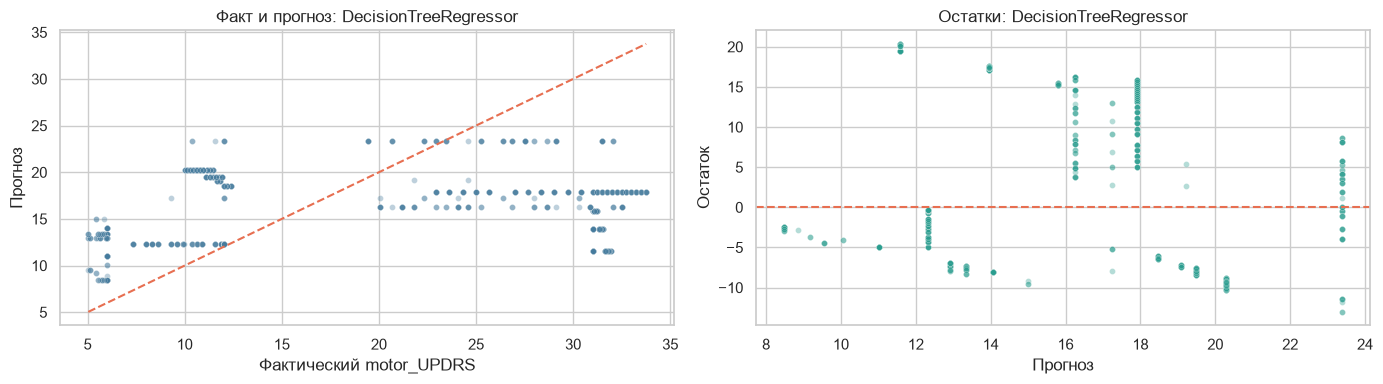

In [27]:
# Дерево решений
print("АРХИТЕКТУРА, КОТОРАЯ ОБУЧАЕТСЯ")
print("DecisionTreeRegressor: max_depth=6, min_samples_leaf=10, criterion=squared_error")
decision_tree = DecisionTreeRegressor(max_depth=6, min_samples_leaf=10, random_state=SEED)
decision_tree.fit(X_class_train, y_class_train)
tree_val_pred = decision_tree.predict(X_class_val)
tree_test_pred = decision_tree.predict(X_class_test)
tree_val_metrics = regression_metrics(y_class_val, tree_val_pred)
tree_test_metrics = regression_metrics(y_class_test, tree_test_pred)
print("Validation:", {k: round(v, 4) for k, v in tree_val_metrics.items()})
print("Test:", {k: round(v, 4) for k, v in tree_test_metrics.items()})
classical_results.append({"model": "DecisionTreeRegressor", "split": "patient-level", "scaling": "не требуется",
                          "val_RMSE": tree_val_metrics["RMSE"], "val_R2": tree_val_metrics["R2"],
                          "test_RMSE": tree_test_metrics["RMSE"], "test_R2": tree_test_metrics["R2"]})
classical_predictions["DecisionTreeRegressor"] = (tree_val_pred, tree_test_pred)
plot_prediction_metrics(y_class_val.values, tree_val_pred, "DecisionTreeRegressor")


### Пояснение

Обучаем градиентный бустинг над деревьями на новых пациентах; validation используется для выбора лучшего числа итераций, test остаётся финальной оценкой.

АРХИТЕКТУРА, КОТОРАЯ ОБУЧАЕТСЯ
CatBoostRegressor: 400 деревьев, depth=6, learning_rate=0.03, loss=RMSE


Validation: {'RMSE': 10.0927, 'R2': 0.0571}
Test: {'RMSE': 8.6371, 'R2': -1.7535}


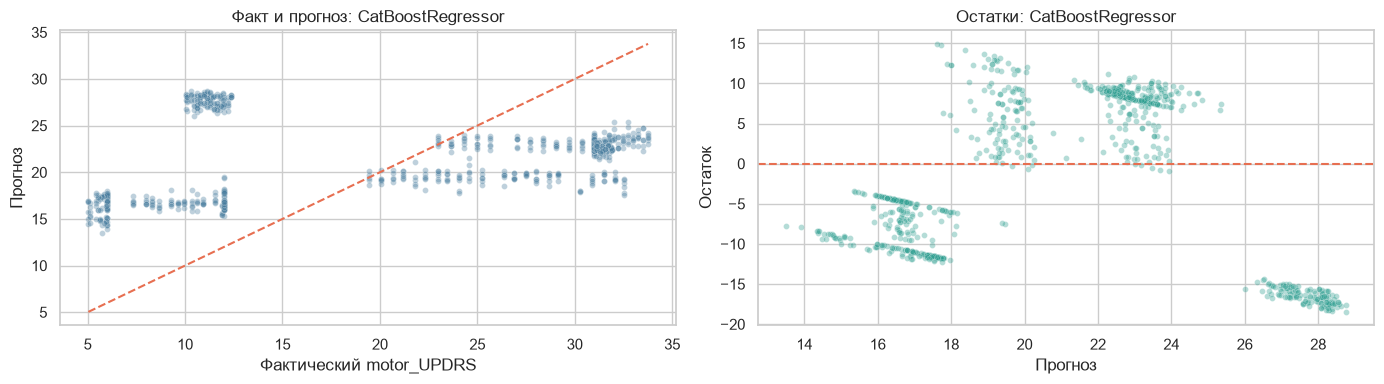

In [28]:
# CatBoostRegressor — градиентный бустинг над деревьями
if CATBOOST_AVAILABLE:
    print("АРХИТЕКТУРА, КОТОРАЯ ОБУЧАЕТСЯ")
    print("CatBoostRegressor: 400 деревьев, depth=6, learning_rate=0.03, loss=RMSE")
    catboost_model = CatBoostRegressor(
        iterations=400, depth=6, learning_rate=0.03, loss_function="RMSE",
        random_seed=SEED, l2_leaf_reg=3.0, verbose=False,
        allow_writing_files=False
    )
    catboost_model.fit(X_class_train, y_class_train, eval_set=(X_class_val, y_class_val),
                       use_best_model=True, verbose=False)
    cat_val_pred = catboost_model.predict(X_class_val)
    cat_test_pred = catboost_model.predict(X_class_test)
    cat_val_metrics = regression_metrics(y_class_val, cat_val_pred)
    cat_test_metrics = regression_metrics(y_class_test, cat_test_pred)
    print("Validation:", {k: round(v, 4) for k, v in cat_val_metrics.items()})
    print("Test:", {k: round(v, 4) for k, v in cat_test_metrics.items()})
    classical_results.append({"model": "CatBoostRegressor", "split": "patient-level", "scaling": "не требуется",
                              "val_RMSE": cat_val_metrics["RMSE"], "val_R2": cat_val_metrics["R2"],
                              "test_RMSE": cat_test_metrics["RMSE"], "test_R2": cat_test_metrics["R2"]})
    classical_predictions["CatBoostRegressor"] = (cat_val_pred, cat_test_pred)
    plot_prediction_metrics(y_class_val.values, cat_val_pred, "CatBoostRegressor")
else:
    catboost_model = None
    print("CatBoost пропущен: установите пакет catboost и перезапустите эту ячейку.")


### Пояснение

Добавляем полиномиальные взаимодействия второй степени и сравниваем Pipeline со стандартизацией и Min-Max нормализацией, обученными только на train.

АРХИТЕКТУРА, КОТОРАЯ ОБУЧАЕТСЯ
Polynomial + StandardScaler: PolynomialFeatures(degree=2) -> Ridge(alpha=1.0)
Преобразования: fit только на train; validation и test только transform
Validation: {'RMSE': 17.8234, 'R2': -1.9405}
Test: {'RMSE': 12.1842, 'R2': -4.4796}


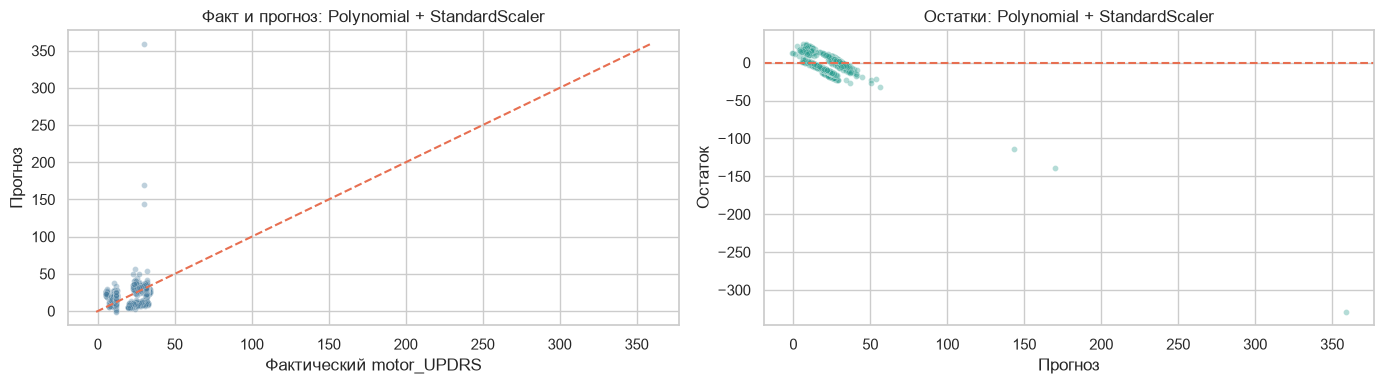

АРХИТЕКТУРА, КОТОРАЯ ОБУЧАЕТСЯ
Polynomial + MinMaxScaler: PolynomialFeatures(degree=2) -> Ridge(alpha=1.0)
Преобразования: fit только на train; validation и test только transform
Validation: {'RMSE': 11.9922, 'R2': -0.3312}
Test: {'RMSE': 11.1778, 'R2': -3.6118}


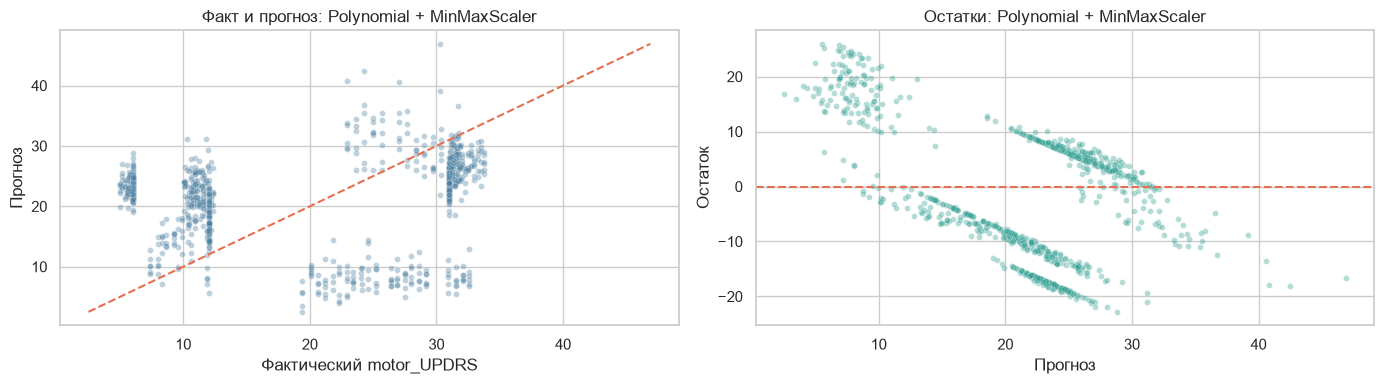

,model,split,scaling,val_RMSE,val_R2,test_RMSE,test_R2
1,CatBoostRegressor,patient-level,не требуется,10.0927,0.0571,8.6371,-1.7535
0,DecisionTreeRegressor,patient-level,не требуется,10.7878,-0.0772,12.1383,-4.4384
3,Polynomial + MinMaxScaler,patient-level,в Pipeline,11.9922,-0.3312,11.1778,-3.6118
2,Polynomial + StandardScaler,patient-level,в Pipeline,17.8234,-1.9405,12.1842,-4.4796


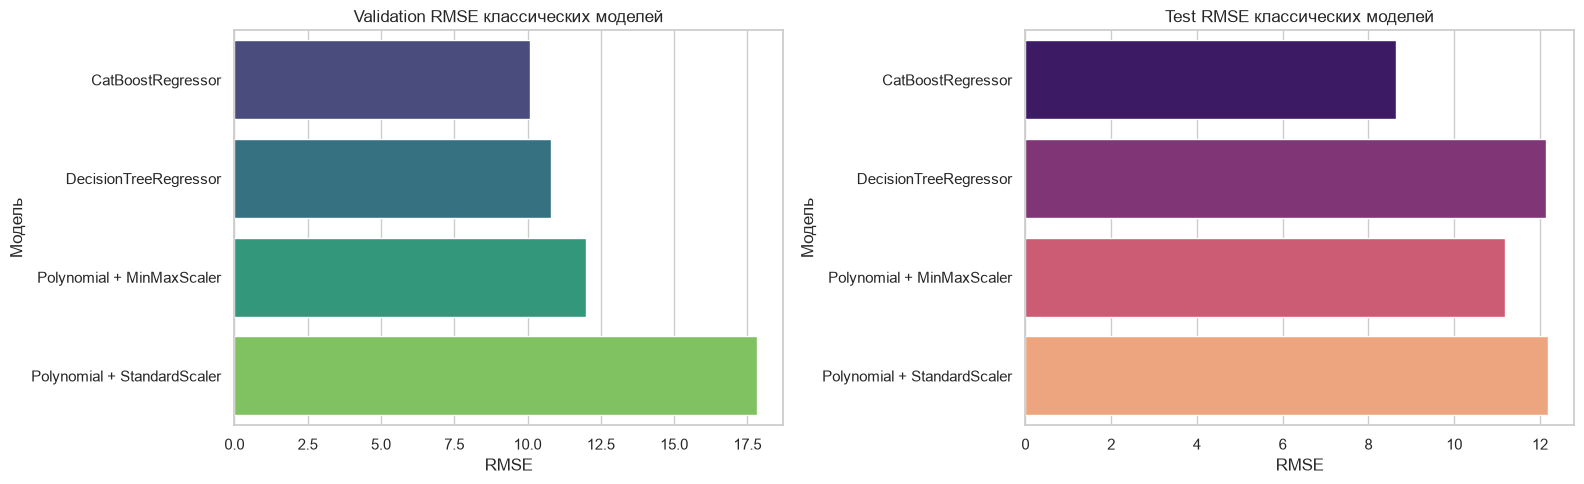

In [29]:
# Полиномиальная регрессия: стандартизация и нормализация
polynomial_models = {
    "Polynomial + StandardScaler": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("standard_scaler", StandardScaler()),
        ("polynomial_features", PolynomialFeatures(degree=2, include_bias=False)),
        ("ridge", Ridge(alpha=1.0)),
    ]),
    "Polynomial + MinMaxScaler": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("minmax_scaler_before_poly", MinMaxScaler()),
        ("polynomial_features", PolynomialFeatures(degree=2, include_bias=False)),
        ("minmax_scaler_after_poly", MinMaxScaler()),
        ("ridge", Ridge(alpha=1.0)),
    ]),
}
polynomial_predictions = {}
for polynomial_name, polynomial_model in polynomial_models.items():
    print("АРХИТЕКТУРА, КОТОРАЯ ОБУЧАЕТСЯ")
    print(f"{polynomial_name}: PolynomialFeatures(degree=2) -> Ridge(alpha=1.0)")
    print("Преобразования: fit только на train; validation и test только transform")
    polynomial_model.fit(X_class_train_raw, y_class_train)
    poly_val_pred = polynomial_model.predict(X_class_val_raw)
    poly_test_pred = polynomial_model.predict(X_class_test_raw)
    poly_val_metrics = regression_metrics(y_class_val, poly_val_pred)
    poly_test_metrics = regression_metrics(y_class_test, poly_test_pred)
    print("Validation:", {k: round(v, 4) for k, v in poly_val_metrics.items()})
    print("Test:", {k: round(v, 4) for k, v in poly_test_metrics.items()})
    classical_results.append({"model": polynomial_name, "split": "patient-level", "scaling": "в Pipeline",
                              "val_RMSE": poly_val_metrics["RMSE"], "val_R2": poly_val_metrics["R2"],
                              "test_RMSE": poly_test_metrics["RMSE"], "test_R2": poly_test_metrics["R2"]})
    polynomial_predictions[polynomial_name] = (poly_val_pred, poly_test_pred)
    plot_prediction_metrics(y_class_val.values, poly_val_pred, polynomial_name)

classical_results_df = pd.DataFrame(classical_results).sort_values("val_RMSE")
display(classical_results_df.round(4))
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=classical_results_df, x="val_RMSE", y="model", hue="model", legend=False, ax=axes[0], palette="viridis")
axes[0].set(title="Validation RMSE классических моделей", xlabel="RMSE", ylabel="Модель")
sns.barplot(data=classical_results_df, x="test_RMSE", y="model", hue="model", legend=False, ax=axes[1], palette="magma")
axes[1].set(title="Test RMSE классических моделей", xlabel="RMSE", ylabel="Модель")
plt.tight_layout(); plt.show()


## Grid Search для GRU

GridSearchCV выполняется на train+validation лучшего по validation RMSE набора GRU. Test-выборка остаётся нетронутой до финальной оценки.


### Пояснение

Создаём оболочку GRU, совместимую с GridSearchCV, чтобы подобрать units, dropout и learning rate.

In [30]:
# sklearn-совместимая оболочка GRU
class GRURegressor(BaseEstimator, RegressorMixin):
    def __init__(self, units=32, dropout=0.1, learning_rate=1e-3, batch_size=64, epochs=50, verbose=0):
        self.units = units
        self.dropout = dropout
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.epochs = epochs
        self.verbose = verbose

    def fit(self, X, y):
        if not TF_AVAILABLE:
            raise RuntimeError("Установите TensorFlow для GridSearchCV.")
        X = np.asarray(X, dtype=np.float32)
        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(SEED)
        self.model_ = build_gru_model(X.shape[1], units=self.units,
                                      learning_rate=self.learning_rate, dropout=self.dropout)
        callbacks = [
            tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
            tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6),
        ]
        self.model_.fit(X.reshape(-1, 1, X.shape[1]), np.asarray(y), validation_split=0.15,
                        epochs=self.epochs, batch_size=self.batch_size, verbose=self.verbose, callbacks=callbacks)
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=np.float32)
        return self.model_.predict(X.reshape(-1, 1, X.shape[1]), verbose=0).ravel()


### Пояснение

Подбираем гиперпараметры GRU на train+validation и не используем test до финального сравнения.

In [31]:
# Запуск Grid Search и финальная оценка настроенной GRU
if TF_AVAILABLE and not comparison_results.empty:
    gru_rows = comparison_results[comparison_results["model"] == "GRU"].sort_values("val_RMSE")
    best_gru_dataset = gru_rows.iloc[0]["dataset"]
    grid_data = dataset_variants[best_gru_dataset]
    X_trainval = np.vstack([grid_data["X_train"], grid_data["X_val"]]).astype(np.float32)
    y_trainval = np.concatenate([y_train.values, y_val.values]).astype(np.float32)

    grid_search = GridSearchCV(
        GRURegressor(batch_size=64, epochs=50, verbose=0),
        param_grid={"units": [32, 64], "dropout": [0.0, 0.2], "learning_rate": [1e-3]},
        scoring="neg_root_mean_squared_error", cv=3, n_jobs=1, return_train_score=True,
    )
    grid_search.fit(X_trainval, y_trainval)
    tuned_test_metrics = regression_metrics(y_test, grid_search.best_estimator_.predict(grid_data["X_test"]))
    baseline = gru_rows.iloc[0]
    baseline_gru_test_metrics = regression_metrics(
        y_test,
        predict_neural_model(model_store[(best_gru_dataset, "GRU")], grid_data["X_test"], recurrent=True),
    )
    before_after = pd.DataFrame([
        {"stage": "GRU до Grid Search (test)", "RMSE": baseline_gru_test_metrics["RMSE"], "R2": baseline_gru_test_metrics["R2"]},
        {"stage": "GRU после Grid Search", "RMSE": tuned_test_metrics["RMSE"], "R2": tuned_test_metrics["R2"]},
    ])
    print("Лучшие гиперпараметры:", grid_search.best_params_)
    display(before_after.round(4))
    display(pd.DataFrame([tuned_test_metrics], index=["tuned_test"]).round(4))
else:
    grid_search = None
    tuned_test_metrics = {}
    print("Grid Search будет выполнен после установки TensorFlow.")


Лучшие гиперпараметры: {'dropout': 0.0, 'learning_rate': 0.001, 'units': 64}


,stage,RMSE,R2
0,GRU до Grid Search (test),6.2948,0.4167
1,GRU после Grid Search,7.2977,0.2161


,RMSE,R2
tuned_test,7.2977,0.2161


## Полноценная временная постановка для GRU

В предыдущем эксперименте каждая строка подавалась как последовательность длиной 1. Теперь записи группируются по пациентам и сортируются по test_time. Каждые 10 прошлых измерений используются для прогноза следующего motor_UPDRS. Разбиение выполняется по пациентам, чтобы один пациент не оказался одновременно в train и test.


### Пояснение

Строим полноценные временные окна длиной 10 внутри каждого пациента и обучаем последовательностную GRU на прогноз следующего motor_UPDRS.

Форма последовательностей: {'train': (3817, 10, 19), 'validation': (745, 10, 19), 'test': (893, 10, 19)}
Пациенты: {'train': 29, 'validation': 6, 'test': 7}
Признаки на одном временном шаге: ['age', 'sex', 'test_time', 'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP', 'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE']


АРХИТЕКТУРА, КОТОРАЯ ОБУЧАЕТСЯ


Последовательностная GRU: окно 10, GRU(64, activation=tanh), Dense(32, activation=tanh), Dense(1)
Инициализация: GlorotUniform для входных весов, Orthogonal для рекуррентных весов
Регуляризация: нет; EarlyStopping и ReduceLROnPlateau включены


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        16,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,433 (72.00 KB)

 Trainable params: 18,433 (72.00 KB)

 Non-trainable params: 0 (0.00 B)

Метрики GRU на временных рядах: {'RMSE': 5.0768, 'R2': -0.0006}


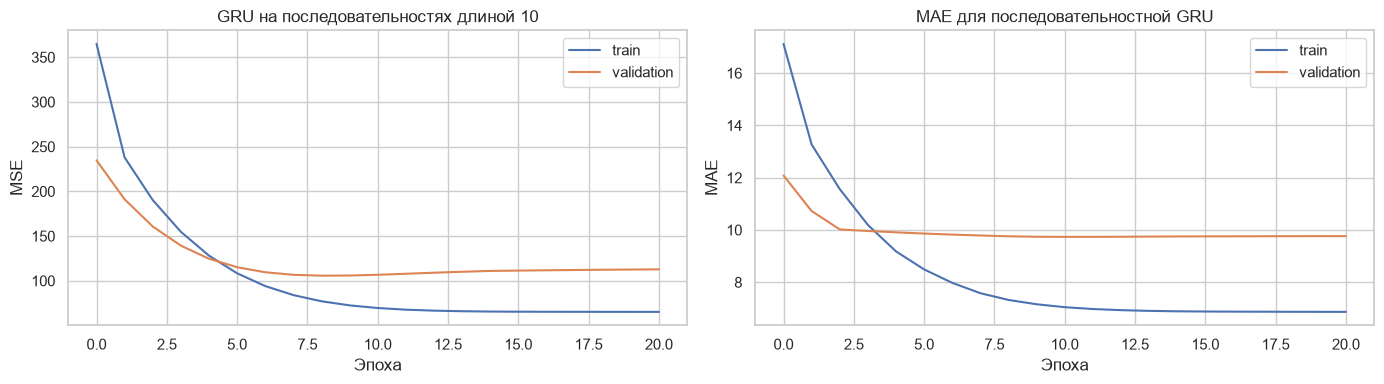

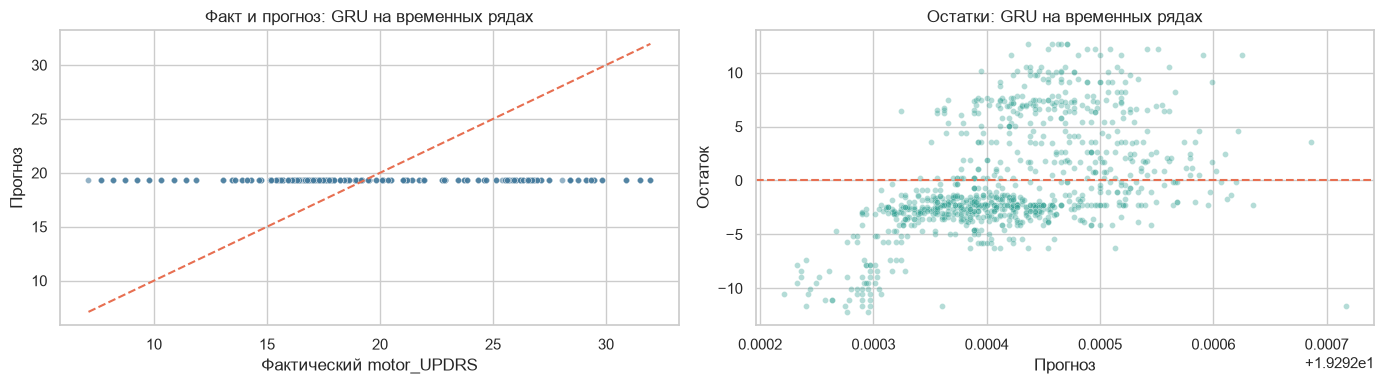

In [32]:
# Преобразование табличных измерений в временные последовательности и обучение GRU
SEQUENCE_LENGTH = 10
sequence_df = df_raw.drop_duplicates().sort_values([ID_COLUMN, "test_time"]).copy()
sequence_feature_cols = [c for c in df_clean.columns if c != TARGET]

subject_ids = sequence_df[ID_COLUMN].unique()
subject_train, subject_temp = train_test_split(subject_ids, test_size=0.30, random_state=SEED)
subject_val, subject_test = train_test_split(subject_temp, test_size=0.50, random_state=SEED)

sequence_imputer = SimpleImputer(strategy="median")
sequence_scaler = MinMaxScaler()
train_rows = sequence_df[sequence_df[ID_COLUMN].isin(subject_train)]
sequence_imputer.fit(train_rows[sequence_feature_cols])
sequence_scaler.fit(sequence_imputer.transform(train_rows[sequence_feature_cols]))
sequence_df[sequence_feature_cols] = sequence_scaler.transform(
    sequence_imputer.transform(sequence_df[sequence_feature_cols])
)

def make_patient_sequences(frame, subjects, feature_cols, target, sequence_length):
    X_seq, y_seq, groups = [], [], []
    for subject, group in frame[frame[ID_COLUMN].isin(subjects)].groupby(ID_COLUMN):
        group = group.sort_values("test_time")
        values = group[feature_cols].to_numpy(dtype=np.float32)
        targets = group[target].to_numpy(dtype=np.float32)
        for end in range(sequence_length, len(group)):
            X_seq.append(values[end-sequence_length:end])
            y_seq.append(targets[end])
            groups.append(subject)
    return np.asarray(X_seq), np.asarray(y_seq), np.asarray(groups)

X_seq_train, y_seq_train, groups_train = make_patient_sequences(
    sequence_df, subject_train, sequence_feature_cols, TARGET, SEQUENCE_LENGTH
)
X_seq_val, y_seq_val, groups_val = make_patient_sequences(
    sequence_df, subject_val, sequence_feature_cols, TARGET, SEQUENCE_LENGTH
)
X_seq_test, y_seq_test, groups_test = make_patient_sequences(
    sequence_df, subject_test, sequence_feature_cols, TARGET, SEQUENCE_LENGTH
)

print("Форма последовательностей:", {
    "train": X_seq_train.shape,
    "validation": X_seq_val.shape,
    "test": X_seq_test.shape,
})
print("Пациенты:", {"train": len(subject_train), "validation": len(subject_val), "test": len(subject_test)})
print("Признаки на одном временном шаге:", sequence_feature_cols)

if TF_AVAILABLE:
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)
    print("АРХИТЕКТУРА, КОТОРАЯ ОБУЧАЕТСЯ")
    print("Последовательностная GRU: окно 10, GRU(64, activation=tanh), Dense(32, activation=tanh), Dense(1)")
    print("Инициализация: GlorotUniform для входных весов, Orthogonal для рекуррентных весов")
    print("Регуляризация: нет; EarlyStopping и ReduceLROnPlateau включены")
    sequence_gru = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(SEQUENCE_LENGTH, len(sequence_feature_cols))),
        tf.keras.layers.GRU(64, activation="tanh", kernel_initializer="glorot_uniform",
                            recurrent_initializer="orthogonal"),
        tf.keras.layers.Dense(32, activation="tanh", kernel_initializer="glorot_uniform"),
        tf.keras.layers.Dense(1),
    ])
    sequence_gru.summary()
    sequence_gru.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss="mse", metrics=["mae"])
    sequence_callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=6, min_lr=1e-6),
    ]
    sequence_history = sequence_gru.fit(
        X_seq_train, y_seq_train,
        validation_data=(X_seq_val, y_seq_val),
        epochs=80, batch_size=64, verbose=0, callbacks=sequence_callbacks,
    )
    sequence_test_pred = sequence_gru.predict(X_seq_test, verbose=0).ravel()
    sequence_test_metrics = regression_metrics(y_seq_test, sequence_test_pred)
    print("Метрики GRU на временных рядах:", {k: round(v, 4) for k, v in sequence_test_metrics.items()})

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(sequence_history.history["loss"], label="train")
    axes[0].plot(sequence_history.history["val_loss"], label="validation")
    axes[0].set(title="GRU на последовательностях длиной 10", xlabel="Эпоха", ylabel="MSE")
    axes[0].legend()
    axes[1].plot(sequence_history.history["mae"], label="train")
    axes[1].plot(sequence_history.history["val_mae"], label="validation")
    axes[1].set(title="MAE для последовательностной GRU", xlabel="Эпоха", ylabel="MAE")
    axes[1].legend()
    plt.tight_layout(); plt.show()
    plot_prediction_metrics(y_seq_test, sequence_test_pred, "GRU на временных рядах")
else:
    sequence_gru = None
    sequence_history = None
    sequence_test_metrics = {}
    print("Установите TensorFlow для обучения последовательностной GRU.")


### Пояснение

Сопоставляем GRU с одним временным шагом и GRU, которая получает историю из десяти измерений.

In [33]:
# Сравнение табличной GRU и последовательностной GRU
if TF_AVAILABLE and not comparison_results.empty:
    tabular_gru = comparison_results[comparison_results["model"] == "GRU"].sort_values("val_RMSE").iloc[0]
    sequence_comparison = pd.DataFrame([
        {"model": "GRU: одна строка как 1 шаг", "dataset": tabular_gru["dataset"],
         "RMSE": float(tabular_gru["val_RMSE"]), "R2": float(tabular_gru["val_R2"]), "sample": "validation"},
        {"model": "GRU: окно 10 измерений", "dataset": "patient time series",
         "RMSE": sequence_test_metrics["RMSE"], "R2": sequence_test_metrics["R2"], "sample": "test"},
    ])
    display(sequence_comparison.round(4))


,model,dataset,RMSE,R2,sample
0,GRU: одна строка как 1 шаг,transformed_original,6.0348,0.4160,validation
1,GRU: окно 10 измерений,patient time series,5.0768,-0.0006,test


### Пояснение

Фиксируем контроль требований лабораторной работы и формулируем итоговые выводы по очистке, моделям, метрикам, утечке и временным рядам.

In [34]:
# Итоговые выводы и контроль требований
print("КОНТРОЛЬ РЕЗУЛЬТАТА")
print(f"1. Источник данных: {DATA_SOURCE}")
print(f"2. Целевая переменная: {TARGET}")
print(f"3. {LEAKAGE_COLUMN} удалён: {LEAKAGE_COLUMN not in df_clean.columns}")
print(f"4. {ID_COLUMN} удалён: {ID_COLUMN not in df_clean.columns}")
print(f"5. Дубликатов после очистки: {int(df_clean.duplicated().sum())}")
print(f"6. Пропусков в подготовленных train-признаках: {sum(np.isnan(d['X_train']).sum() for d in dataset_variants.values())}")
print("7. Журнал удалённых признаков:")
display(removal_log if not removal_log.empty else
        pd.DataFrame({"feature": ["<нет>"], "reason": ["Порог почти нулевой вариативности не сработал"]}))

if TF_AVAILABLE and not comparison_results.empty:
    final_row = comparison_results.iloc[0]
    print(f"8. Лучшая validation-модель: {final_row['model']} на наборе {final_row['dataset']}")
    print("9. Test-оценка и Grid Search выполнены.")
else:
    print("8-9. Метрики моделей и Grid Search требуют TensorFlow.")
if TF_AVAILABLE and not experiment_results.empty:
    print("10. Проведены эксперименты с ReLU, tanh, разными инициализациями и архитектурами.")
    print("11. Регуляризация L2 + Dropout проверена в отдельном блоке, а не применялась ко всем базовым экспериментам.")
    print("12. Для каждого эксперимента построены learning curves и графики качества прогноза.")
    print("13. Лучший эксперимент по validation:")
    display(experiment_results.head(1).round(4))
if not classical_results_df.empty:
    print("14. Классические модели проверены на тех же train/validation/test-разбиениях без утечки данных.")
    print("15. Для полиномиальных моделей стандартизация и нормализация выполнялись внутри Pipeline только по train.")
    print("16. Лучшая классическая модель по validation:")
    display(classical_results_df.head(1).round(4))
display(Markdown('''### Интерпретация

motor_UPDRS прогнозируется по голосовым измерениям, возрасту, полу и времени наблюдения. total_UPDRS исключён как утечка информации. При выводах следует ориентироваться на validation RMSE/R², а окончательное качество подтверждать только на test. Эксперименты показывают влияние активации tanh, начальной инициализации и глубины сети. Отдельное сравнение L2-регуляризации и Dropout позволяет оценить их влияние на переобучение. Последней частью работы является сравнение моделей и итоговая интерпретация результатов.'''))


КОНТРОЛЬ РЕЗУЛЬТАТА
1. Источник данных: UCI: https://archive.ics.uci.edu/static/public/189/parkinsons+telemonitoring.zip
2. Целевая переменная: motor_UPDRS
3. total_UPDRS удалён: True
4. subject# удалён: True
5. Дубликатов после очистки: 0
6. Пропусков в подготовленных train-признаках: 0
7. Журнал удалённых признаков:


,feature,reason
0,subject#,идентификатор пациента; не является измеряемым...
1,total_UPDRS,утечка целевой информации; запрещён входным ус...


8. Лучшая validation-модель: Dense на наборе transformed_original
9. Test-оценка и Grid Search выполнены.
10. Проведены эксперименты с ReLU, tanh, разными инициализациями и архитектурами.
11. Регуляризация L2 + Dropout проверена в отдельном блоке, а не применялась ко всем базовым экспериментам.
12. Для каждого эксперимента построены learning curves и графики качества прогноза.
13. Лучший эксперимент по validation:


,experiment,model,activation,initializer,recurrent_initializer,regularization,train_RMSE,train_R2,val_RMSE,val_R2,epochs_used
4,"Глубокая GRU: tanh + два Dense-слоя, без регул...",GRU,tanh,glorot_uniform,orthogonal,нет,6.1775,0.4258,5.9458,0.4331,60


14. Классические модели проверены на тех же train/validation/test-разбиениях без утечки данных.
15. Для полиномиальных моделей стандартизация и нормализация выполнялись внутри Pipeline только по train.
16. Лучшая классическая модель по validation:


,model,split,scaling,val_RMSE,val_R2,test_RMSE,test_R2
1,CatBoostRegressor,patient-level,не требуется,10.0927,0.0571,8.6371,-1.7535


### Интерпретация

motor_UPDRS прогнозируется по голосовым измерениям, возрасту, полу и времени наблюдения. total_UPDRS исключён как утечка информации. При выводах следует ориентироваться на validation RMSE/R², а окончательное качество подтверждать только на test. Эксперименты показывают влияние активации tanh, начальной инициализации и глубины сети. Отдельное сравнение L2-регуляризации и Dropout позволяет оценить их влияние на переобучение. Последней частью работы является сравнение моделей и итоговая интерпретация результатов.